<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [1]:
import os
import sys

path = os.getcwd().split("/")[:-1]
path = "/".join(path)
sys.path.append(path)

from models.normPSM import NormPSM
from models.gaModel import GAModel
from models.lognormPSM import LogNormPSM
from utils.plot_funcs import get_percentiles, custom_percentile_cmap, get_sticks
from IPython.display import Image, display, HTML, SVG
import numpy as np
import math
import time
import pandas as pd
from datetime import date

import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D 
import matplotlib.colors as colors
import seaborn as sns
sns.set(style="whitegrid")
%matplotlib notebook
%matplotlib widget
%matplotlib inline
plt.style.use('seaborn-v0_8')
plt.rcParams['legend.labelcolor'] = '#595959'
plt.rcParams['axes.labelcolor'] = '#595959'
plt.rcParams['xtick.color'] = '#595959'
plt.rcParams['ytick.color'] = '#595959'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.grid'] = False


In [2]:
def today():
    return str(date.today()).replace("-", "")

os.makedirs(f"../temp_jupyter_plots/{today()}", exist_ok=True)

## Initial Values of System

**M**: *int* = Num of sequences;

**n_max**: *int* = Number of pairs in native arrangment, where n in {0, ..., M};

**n_bins**: *int* = Number of intervals in I;

**i_nat**: *float* = Value of i for native arrangment;

**i_0**: *float* = I mean for arrangments with n = 0;

**sigma2_0**: *float* = Variance of I for arrangments with n = 0;

**n_step**: *int* = Max n transition in genetic algorithm.

In [3]:
M = 10
n_max = M + 1 
n_bins = M + 1 
i_nat = 50
i_0 = 10 
sigma2_0 = 1
n_step = 1
minimize=False

## **Protein System Model Instance**

norm_poison_probs sum = 0.9999999899522337
reass_norm_poison_probs sum = 0.999999989952234
reass_norm_poison_probs sum = 0.9999999899522334
reass_norm_poison_probs sum = 0.9999999899522344
reass_norm_poison_probs sum = 0.9999999899522337
reass_norm_poison_probs sum = 0.9999999899522334
reass_norm_poison_probs sum = 0.9999999899522336
reass_norm_poison_probs sum = 0.9999999899522337


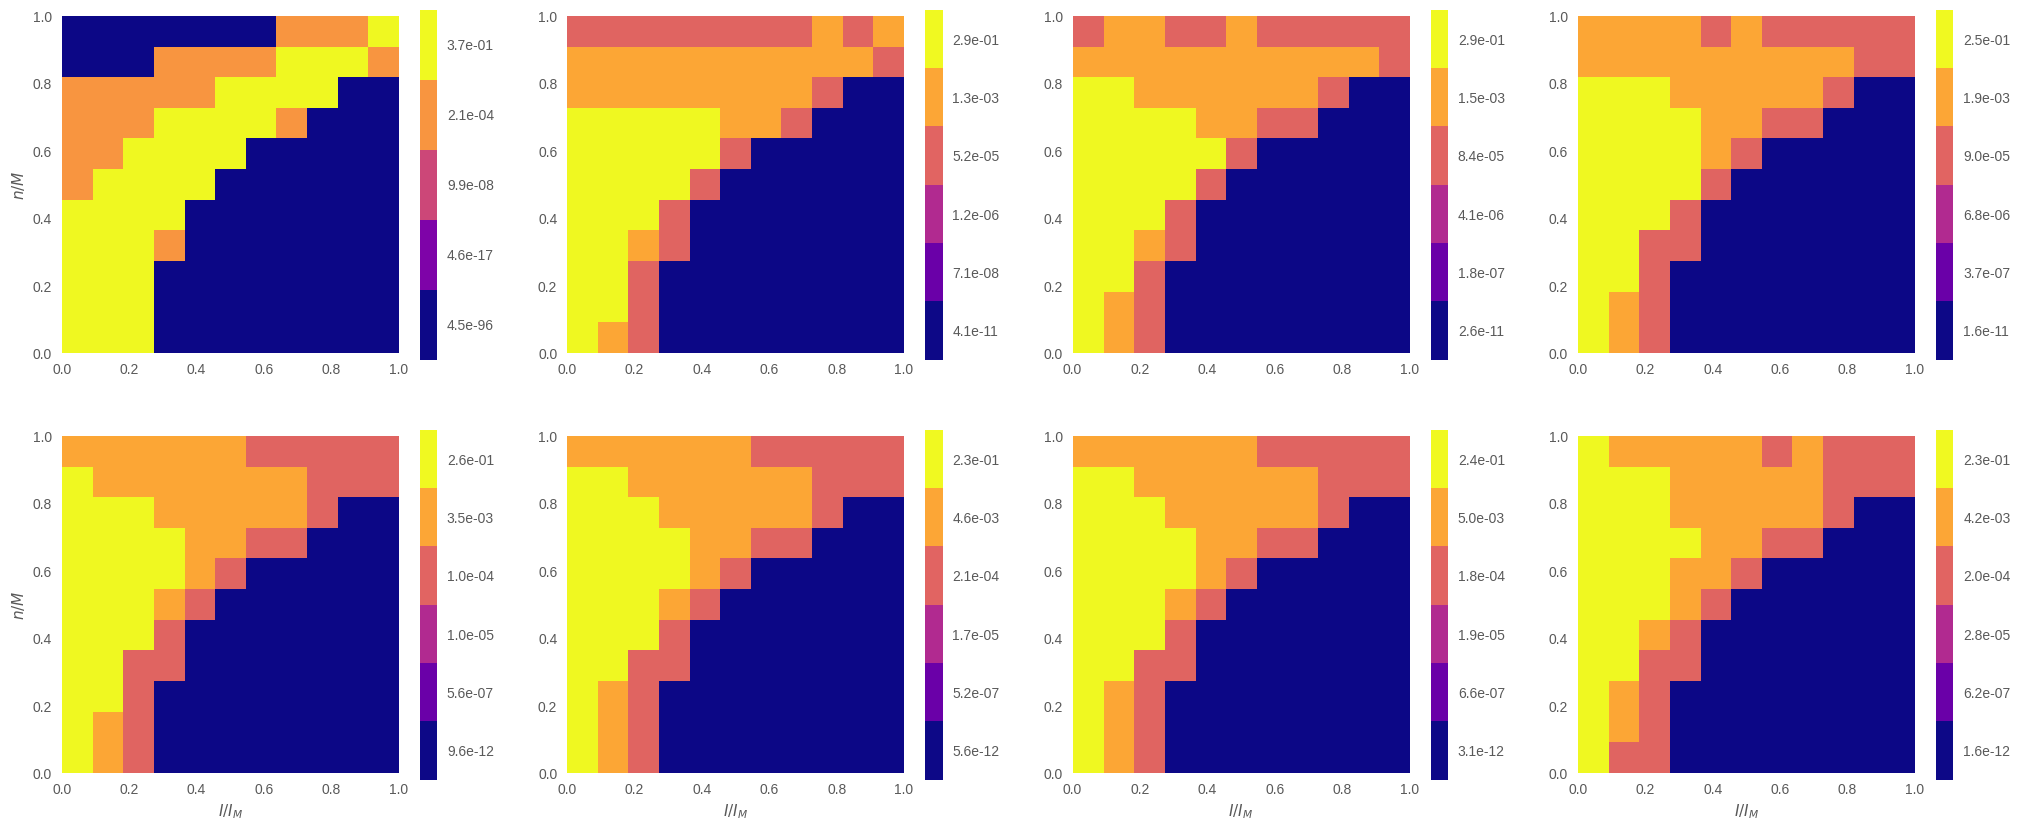

In [4]:
fig, axs = plt.subplots(2, 4, figsize=(25, 10))

plt.grid(False)
cmap = custom_percentile_cmap

norm_psm = NormPSM(M, i_0, i_nat, sigma2_0, n_bins)
# get data
norm_data, norm_bins_center = norm_psm.create_data()

# probs with Poisson weight
norm_poison_probs = norm_psm.get_probs()
print(f"norm_poison_probs sum = {np.sum(norm_poison_probs)}")

for idx, p in enumerate([0.05, 0.1, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]):

    idx1 = int(idx / 4)
    idx2 = idx % 4

    if idx == 0:
        prob_arr = norm_poison_probs
        p = 0.0
    else:
        prob_arr = norm_psm.reassessment_probs(norm_poison_probs, p=p)
        print(f"reass_norm_poison_probs sum = {np.sum(prob_arr)}")
    prob_arr_viz, value_map = get_percentiles(prob_arr)
    ga_model = GAModel()
    init_state = [10, 0] if minimize else list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
    path = ga_model.get_best_path(prob_arr, minimize=minimize, init_state=init_state)[0]
    z_prob = np.fliplr(prob_arr_viz[::-1]) if minimize else prob_arr_viz[::-1]
    c = axs[idx1, idx2].imshow(z_prob, extent=[0, 1, 0, 1], 
                               cmap=cmap(len(value_map)),  interpolation='nearest')
    x = [(x[1] / n_bins) + 0.5 * 1 / n_bins for x in path]
    y = [(x[0] / (n_max)) + 0.5 * 1 / (n_max) for x in path]
    cbar = fig.colorbar(c, ax=axs[idx1, idx2])
    cticks = get_sticks(len(value_map))
    ctick_labels = [f"{x:.1e}" for x in value_map]
    cbar.set_ticks(cticks)
    cbar.set_ticklabels(ctick_labels)
    #axs[idx1, idx2].plot(x, y, '-.', lw=2, color='#3c3f40')
    #axs[idx1, idx2].plot([x[0], x[-1]], [y[0], y[-1]], 'o', lw=2, color='#3c3f40')
    #axs[idx1, idx2].set_title("".join([r'$I _{0}$', f": {i_0};  ",
    #                                   r'$I _{M}$', f": {i_nat};  ",
    #                                   r'$\sigma _{0} ^{2}$', f" :{sigma2_0}; ", f"p={p}"]))
    
    if idx2 == 0:
        axs[idx1, idx2].set_ylabel(r"$n / M$")
    if idx1 == 1:
        axs[idx1, idx2].set_xlabel(r"$I / I_M$")


plt.savefig(f"../temp_jupyter_plots/{today()}/reass_p_diff_M{M}_{today()}.png")
plt.savefig(f"../temp_jupyter_plots/{today()}/reass_p_diff_M{M}_{today()}.svg")

In [5]:
norm_psm = NormPSM(M, i_0, i_nat, sigma2_0, n_bins, verbose=True)

ProteinSystemModel: [M=10, i0=10, inat=50, sigma20=1, nbins=11]


ProteinSystemModel: [M=10, i0=10, inat=50, sigma20=1, nbins=11]
ProteinSystemModel: [M=20, i0=10, inat=50, sigma20=1, nbins=11]
ProteinSystemModel: [M=50, i0=10, inat=50, sigma20=1, nbins=11]
ProteinSystemModel: [M=100, i0=10, inat=50, sigma20=1, nbins=11]


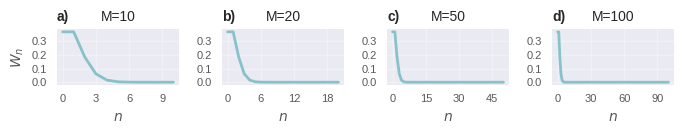

In [6]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1, 4, figsize=(7,1.5))
ax[0].set_title("a)", loc='left', fontweight='bold', fontsize=10)
ax[1].set_title("b)", loc='left', fontweight='bold', fontsize=10)
ax[2].set_title("c)", loc='left', fontweight='bold', fontsize=10)
ax[3].set_title("d)", loc='left', fontweight='bold', fontsize=10)
for idx, M in enumerate([10, 20, 50, 100]):
    norm_psm = NormPSM(M, i_0, i_nat, sigma2_0, n_bins, verbose=True)
    x = norm_psm.get_poisson_weights()
    ax[idx].plot(np.arange(len(x)), x, color="#87c2ca", lw=2)
    ax[idx].set_title(f"M={M}", fontsize=10)
    ax[idx].set_xlabel(r"$n$", fontsize=10)
    if idx == 0:
        ax[idx].set_ylabel(r"$W_{n}$", fontsize=10)
    ax[idx].grid(True, alpha=0.3)
    ax[idx].xaxis.set_major_locator(MaxNLocator(4))
    ax[idx].yaxis.set_major_locator(MaxNLocator(5))
    ax[idx].tick_params(axis='both', which='major', labelsize=8)  # Ticks principais
    ax[idx].tick_params(axis='both', which='minor', labelsize=8)

fig.tight_layout()
plt.savefig(f"../temp_jupyter_plots/{today()}/w_convergence_M{M}_{today()}.png", dpi=300)
plt.savefig(f"../temp_jupyter_plots/{today()}/w_convergence_M{M}_{today()}.svg", dpi=300)

## **Parametric Equations**

In [7]:
df = pd.read_csv("real_system_stats_files/data_systems.csv", header=[0, 1])
systems_alphas = [0.014404, 0.033669, 0.041331, 0.026800, 0.027505, 0.037484, 0.009639]
df.head()

Group 1BXR_AB                     2D1P_BC                      3RRL_AB  \
  Subgroup  sample   i(mean)       var  sample    i(mean)       var  sample   
0        0       0  4.796552  0.005248       0  10.867095  0.034630       0   
1        1      20  4.847256  0.005997       4  10.930916  0.035395      27   
2        2      40  4.909477  0.006840       8  11.001754  0.036697      54   
3        3      61  4.994157  0.007946      13  11.085695  0.038072      81   
4        4      81  5.077096  0.009115      17  11.174869  0.040232     108   

                       ...   2Y69_AC 1EP3_AB                     2Y69_AB  \
    i(mean)       var  ...       var  sample   i(mean)       var  sample   
0  7.433707  0.009315  ...  0.024166       0  7.931804  0.027227       0   
1  7.479922  0.010806  ...  0.027277      11  7.992453  0.030826      30   
2  7.563172  0.013888  ...  0.031941      22  8.064735  0.034526      60   
3  7.689149  0.019225  ...  0.037321      33  8.127919  0.038411      90   
4  7.847443  0.026800  ...  0.044339      45  8.221349  0.042797     121   

                       1RM6_AB                      
     i(mean)       var  sample   i(mean)       var  
0  10.331548  0.008761       0  3.531432  0.001896  
1  10.426342  0.010166      32  3.546817  0.001979  
2  10.546442  0.013175      65  3.573558  0.002086  
3  10.707616  0.018004      98  3.606737  0.002334  
4  10.914087  0.025481     130  3.653333  0.002730  

[5 rows x 22 columns]

In [8]:
systems = list(df.columns.levels[0])
systems.pop()

'Group'

In [9]:
a=np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
np.where((a[:, 0] > 0) & (a[:, 1] < 1))


(array([2]),)

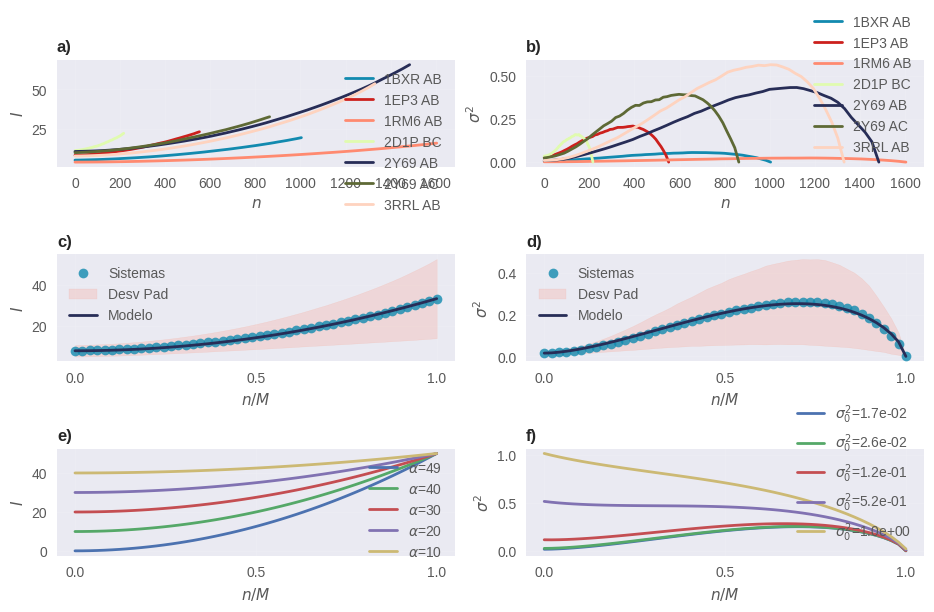

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(3, 2, figsize=(9.5, 6))

# # Definindo os títulos dos subplots
# axs[0, 0].set_title("Information (mean)", loc='left')
# axs[0, 1].set_title("Variance", loc='left')
# axs[1, 0].set_title("Mean information (mean)", loc='left')
# axs[1, 1].set_title("Mean Variance", loc='left')
# axs[2, 0].set_title("Model information fit", loc='left')
# axs[2, 1].set_title("Model variance fit", loc='left')

axs[0, 0].set_title("a)", loc='left', fontweight='bold', fontsize=12)
axs[0, 1].set_title("b)", loc='left', fontweight='bold', fontsize=12)
axs[1, 0].set_title("c)", loc='left', fontweight='bold', fontsize=12)
axs[1, 1].set_title("d)", loc='left', fontweight='bold', fontsize=12)
axs[2, 0].set_title("e)", loc='left', fontweight='bold', fontsize=12)
axs[2, 1].set_title("f)", loc='left', fontweight='bold', fontsize=12)

axs[0, 0].grid(True, which='both', alpha=0.1)
axs[0, 1].grid(True, which='both', alpha=0.1)
axs[1, 0].grid(True, which='both', alpha=0.1)
axs[1, 1].grid(True, which='both', alpha=0.1)
axs[2, 0].grid(True, which='both', alpha=0.1)
axs[2, 1].grid(True, which='both', alpha=0.1)

systems_colors = ['#128aaf', '#cc201d', '#ff8a70', '#e0fbaf', '#272d57', '#5e6935', '#fed3bf']



# Plotando para cada sistema
for idx, system in enumerate(systems):
    ################################ 1, 1 ############################################################## 
    
    axs[0, 0].plot(df[system]["sample"], df[system]["i(mean)"], label=f"{system}".replace("_", " "), color=systems_colors[idx])
    axs[0, 0].set_xlabel(r"$n$")
    axs[0, 0].set_ylabel(r"$I$")
    

    ################################ 1, 2 ############################################################## 
    axs[0, 1].plot(df[system]["sample"], df[system]["var"], label=f"{system}".replace("_", " "), color=systems_colors[idx])
    axs[0, 1].set_xlabel(r"$n$")
    axs[0, 1].set_ylabel(r"$\sigma ^2$")

axs[0, 0].legend(fontsize=10)
axs[0, 1].legend(fontsize=10)

# Calculando as médias e desvios padrão
means_means = df[[(system, "i(mean)") for system in systems]].mean(axis=1)
std_means = df[[(system, "i(mean)") for system in systems]].std(axis=1)
means_means_upper = means_means + std_means
means_means_lower = means_means - std_means

means_var = df[[(system, "var") for system in systems]].mean(axis=1)
std_var = df[[(system, "var") for system in systems]].std(axis=1)
means_var_upper = means_var + std_var
means_var_lower = means_var - std_var

x = np.arange(len(means_means))
n_plotly = len(x)
M_plotly = n_plotly - 1
norm_sample = x / M_plotly

# Criando o modelo norm_psm e calculando expectativas e variâncias
norm_psm = NormPSM(M_plotly, means_means.iloc[0], means_means.iloc[-1], means_var.iloc[0], n_plotly)
expecs = [norm_psm.expec_ns(n) for n in range(n_plotly)]
sigmas2 = [norm_psm.sigma2_ns(n) for n in range(n_plotly)]

#################################### 2, 1 ############################################################## 
axs[1, 0].plot(norm_sample, means_means, 'o', label="Sistemas", alpha=0.8, color='#128aaf')
axs[1, 0].fill_between(norm_sample, means_means_upper, means_means_lower, color='#ff8a70', alpha=0.2, label='Desv Pad')
axs[1, 0].plot(norm_sample, expecs, label="Modelo", color='#272d57')
axs[1, 0].set_xlabel(r"$n / M$")
axs[1, 0].set_ylabel(r"$I$")
axs[1, 0].set_xticks([0.0, 0.5, 1.0])
axs[1, 0].legend(fontsize=10)

#################################### 2, 2 ############################################################## 
axs[1, 1].plot(norm_sample, means_var, 'o', label="Sistemas", alpha=0.8,color='#128aaf')
axs[1, 1].fill_between(norm_sample, means_var_upper, means_var_lower, color='#ff8a70', alpha=0.2, label='Desv Pad')
axs[1, 1].plot(norm_sample, sigmas2, label="Modelo", color='#272d57')
axs[1, 1].set_xlabel(r"$n / M$")
axs[1, 1].set_ylabel(r"$\sigma ^2$")
axs[1, 1].set_xticks([0.0, 0.5, 1.0])
axs[1, 1].legend(fontsize=10)

#################################### 3, 1 ############################################################## 
i0s_sample = [0.1, 10, 20, 30, 40]
for i in i0s_sample:
    norm_psm = NormPSM(M_plotly, i, 50, means_var.iloc[0], n_plotly)
    expecs = [norm_psm.expec_ns(n) for n in range(n_plotly)]
    axs[2, 0].plot(norm_sample, expecs, label=r'$\alpha$'+f"={int(50 - i)}")
axs[2, 0].set_xlabel(r"$n / M$")
axs[2, 0].set_ylabel(r"$I$")
axs[2, 0].set_xticks([0.0, 0.5, 1.0])
axs[2, 0].legend(fontsize=10)

#################################### 3, 2 ############################################################## 
sigmas2_sample = [0.001, 0.01, 0.1, 0.5, 1]
for i in sigmas2_sample:
    norm_psm = NormPSM(M_plotly, means_means.iloc[0], means_means.iloc[-1], means_var.iloc[0] + i, n_plotly)
    sigmas2 = [norm_psm.sigma2_ns(n) for n in range(n_plotly)]
    axs[2, 1].plot(norm_sample, sigmas2, label=r'$\sigma_{0}^{2}$'+f"={means_var.iloc[0] + i:.1e}")
axs[2, 1].set_xlabel(r"$n / M$")
axs[2, 1].set_ylabel(r"$\sigma ^2$")
axs[2, 1].set_xticks([0.0, 0.5, 1.0])
axs[2, 1].legend(fontsize=10)

# Ajustando layout e salvando a imagem
plt.tight_layout()
plt.savefig(f"../temp_jupyter_plots/{today()}/params_systems_{today()}.png")
plt.savefig(f"../temp_jupyter_plots/{today()}/params_systems_{today()}.svg")
plt.show()


In [11]:
display(HTML("""
    <div style="text-align: left; margin-right: 50px;">
        <h3>New Param. Eq.</h3>
        <img src='../media/parametric_equations.png' style="width: 300px;">
    </div>
"""))

In [5]:
# data model:

M_1bxr = 1004
i_0_1bxr = 4.717
i_nat_1bxr = 19.19
n_bins_1bxr = M_1bxr + 1
sigma2_0_1bxr = 0.007

norm_psm_p = NormPSM(M_1bxr, i_0_1bxr, i_nat_1bxr, sigma2_0_1bxr, n_bins_1bxr * 10)
norm_data_p, norm_bins_center_p = norm_psm_p.create_data()
norm_pdfs_p, _p = norm_psm_p.get_prob_bins()

norm_psm = NormPSM(M_1bxr, i_0_1bxr, i_nat_1bxr, sigma2_0_1bxr, n_bins_1bxr)
norm_data, norm_bins_center = norm_psm.create_data()
norm_pdfs, _ = norm_psm.get_prob_bins()

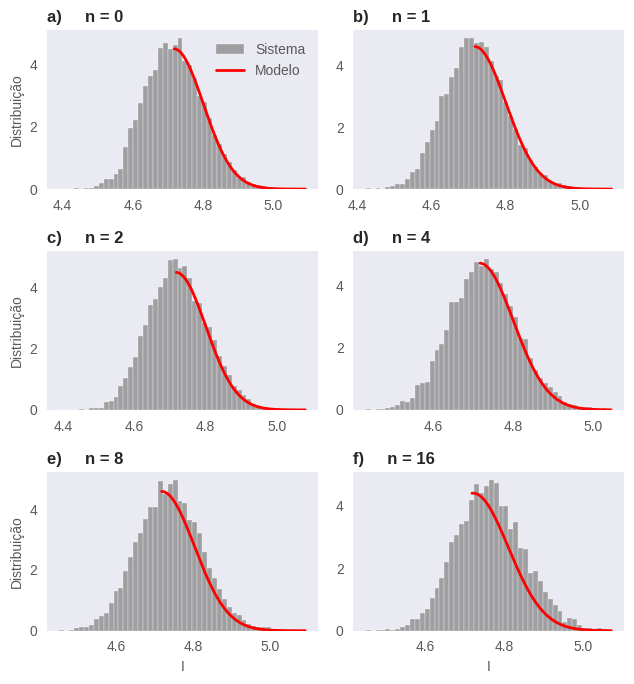

In [7]:


# data rencountres:

path_data = "../jao_data/random_mi_genomes/"
data_file = "MI_FOR_GENOME_1BXR_AB.npy"
sample = [0, 1, 2, 4, 8, 16]


fig = plt.figure(figsize=(6.5, 7.0))
gs = fig.add_gridspec(3, 2)
letters = ["a", "b", "c", "d", "e", "f"]

for idx, n in enumerate(sample):

    row = int(idx / 2)
    col = idx % 2


    data_n = np.load(f"{path_data}/n{n}/{data_file}")

    dat_max = np.max(data_n)

    data_model = []
    for data in norm_bins_center_p:
        if data < dat_max:
            data_model.append(data)


    ax1 = fig.add_subplot(gs[row, col])

    contagem, bins, _ = ax1.hist(data_n, bins=50, density=True, color="grey", alpha=0.7, label="Sistema")

    mean = np.mean(data_n)
    idx_mean = np.abs(bins - mean).argmin()
    fator_ajuste = contagem[idx_mean] / np.mean(data_model)

    ax1.plot(data_model, (norm_pdfs_p[n][:len(data_model)]) * fator_ajuste, c="red", label="Modelo")
    #ax1.set_title(f"n = {n}", fontweight='bold', fontsize=10)
    ax1.set_title(f"{letters[idx]})     n = {n}", loc='left', fontweight='bold', fontsize=12)
    if col == 0:
        ax1.set_ylabel("Distribuição", fontsize=10)
    if row == 2:
        ax1.set_xlabel("I", fontsize=10)
    if idx == 0:
        ax1.legend()
plt.tight_layout()
plt.savefig(f"../temp_jupyter_plots/{today()}/hist_dist_{today()}.png", dpi=300)
plt.savefig(f"../temp_jupyter_plots/{today()}/hist_dist_{today()}.svg", dpi=300)
plt.show()


### **Real Systems Domain**

In [ ]:
df = pd.read_csv("real_system_stats_files/data_samples_systems.csv", header=[0, 1])
df.head()

In [ ]:
i0s_columns = df.loc[:, (slice(None), 'i0s')]
i0s_var_columns = df.loc[:, (slice(None), 'i0s_var')]
natives_columns = df.loc[:, (slice(None), 'natives')]

# Calcula a média das linhas dessas colunas
df['media_i0s'] = i0s_columns.median(axis=1)
df['media_i0s_var'] = i0s_var_columns.median(axis=1)
df['media_natives'] = natives_columns.median(axis=1)

df_stats = df[["media_i0s", "media_i0s_var", "media_natives"]]
df_stats.index = ['10', '20', '30', '40', '50']

# Nomear o índice
df_stats.index.name = 'Sequences'

display(df_stats)

In [ ]:
i0s_columns = df.loc[:, pd.IndexSlice[:, 'i0s_var']]
i0s_mean = i0s_columns.median()
natives_columns = df.loc[:, pd.IndexSlice[:, 'natives']]
natives_mean = natives_columns.median()
print(np.median(i0s_mean), np.median(natives_mean))

In [ ]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter

fig, axs = plt.subplots(1, 4, figsize=(7.4, 1.7))
cmap = custom_percentile_cmap

axs[0].set_title("a)", loc='left', fontweight='bold', fontsize=10, y=1.1)
axs[1].set_title("b)", loc='left', fontweight='bold', fontsize=10, y=1.1)
axs[2].set_title("c)", loc='left', fontweight='bold', fontsize=10, y=1.1)
axs[3].set_title("d)", loc='left', fontweight='bold', fontsize=10, y=1.1)

Ms = [10, 20, 50, 100]

for idx1, M in enumerate(Ms):

    sys_model = NormPSM(M, i_0, i_nat, sigma2_0, n_bins=M+1)
    prob_arr = sys_model.get_probs()
    prob_arr_viz, value_map = get_percentiles(prob_arr)
    ga_model = GAModel()
    init_state = [10] if minimize else list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
    path = ga_model.get_best_path(prob_arr, minimize=minimize, init_state=init_state)[0]
    z_prob = np.fliplr(prob_arr_viz[::-1]) if minimize else prob_arr_viz[::-1]
    c = axs[idx1].imshow(z_prob, extent=[0, 1, 0, 1], 
                               cmap=cmap(len(value_map)),  interpolation='nearest')
    x = [(x[1] / n_bins) + 0.5 * 1 / n_bins for x in path]
    if minimize:
        axs[idx1, idx2].set_xticks(ticks=x, labels=[1.0, "", "", "", "", "", "", "", "", "",0.0])
    y = [(x[0] / (n_max)) + 0.5 * 1 / (n_max) for x in path]
    cbar = fig.colorbar(c, ax=axs[idx1])
    cticks = get_sticks(len(value_map))
    ctick_labels = [f"{x:.1e}" for x in value_map]
    cbar.set_ticks(cticks)
    cbar.set_ticklabels(ctick_labels)
    cbar.ax.tick_params(labelsize=10)
    
    #axs[idx1].plot(x, y, '-', lw=6, color='white', zorder=1)
    #axs[idx1].plot(x, y, '--', lw=4, color='black', zorder=2)
    #axs[idx1].scatter([x[0], x[-1]], [y[0], y[-1]], marker="o", s=200, facecolors='black', edgecolors='white', linewidth=1.5, zorder=3, clip_on=False)
    # axs[idx1, idx2].plot([x[0], x[-1]], [y[0], y[-1]],  marker='o', markersize=10,
    #  markerfacecolor='black', markeredgewidth=2, markeredgecolor='white')
    axs[idx1].set_title(f"M={M}", fontsize=10, y=1.1)
    axs[idx1].set_xlabel("I/I'", fontsize=10)
    if idx1 == 0:
        axs[idx1].set_ylabel("n/M", fontsize=10)
    axs[idx1].grid(False)
    axs[idx1].set_xticks([1])
    axs[idx1].set_yticks([0, 1])
    axs[idx1].tick_params(axis='both', which='major', labelsize=8)  # Ticks principais
    axs[idx1].tick_params(axis='both', which='minor', labelsize=8)
    axs[idx1].set_facecolor('none')       

plt.subplots_adjust(wspace=0.3)
plt.grid(False)


#fig.tight_layout()
plt.savefig(f"../temp_jupyter_plots/{today()}/distribution_path_M{M}_{today()}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"../temp_jupyter_plots/{today()}/distribution_path_M{M}_{today()}.svg", dpi=300, bbox_inches='tight')

## Get best path in GA for a system

In [ ]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter


fig, axs = plt.subplots(4, 4, figsize=(7, 7))
plt.subplots_adjust(wspace=0.001, hspace=0.001)
cmap = custom_percentile_cmap
i_0s = [10, 20, 30, 40] 
sigmas2_0 = [0.001, 0.01, 0.1, 1.0]

for idx1, i0 in enumerate(i_0s):
    for idx2, s0 in enumerate(sigmas2_0):

        sys_model = NormPSM(M, i0, i_nat, s0, n_bins=M+1)
        prob_arr = sys_model.get_probs()
        prob_arr_viz, value_map = get_percentiles(prob_arr)
        ga_model = GAModel()
        init_state = [10] if minimize else list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
        path = ga_model.get_best_path(prob_arr, minimize=minimize, init_state=init_state)[0]
        z_prob = np.fliplr(prob_arr_viz[::-1]) if minimize else prob_arr_viz[::-1]
        c = axs[idx1, idx2].imshow(z_prob, extent=[0, 1, 0, 1], 
                                   cmap=cmap(len(value_map)),  interpolation='nearest')
        x = [(x[1] / n_bins) + 0.5 * 1 / n_bins for x in path]
        if minimize:
            axs[idx1, idx2].set_xticks(ticks=x, labels=[1.0, "", "", "", "", "", "", "", "", "",0.0])
        y = [(x[0] / (n_max)) + 0.5 * 1 / (n_max) for x in path]
        cbar = fig.colorbar(c, ax=axs[idx1, idx2], shrink=0.9)
        cticks = get_sticks(len(value_map))
        ctick_labels = [f"{x:.1e}" for x in value_map]
        cbar.set_ticks(cticks)
        cbar.set_ticklabels(ctick_labels)
        cbar.ax.tick_params(labelsize=8, pad=0.08)
        
        axs[idx1, idx2].plot(x, y, '-', lw=1.5, color='white', zorder=1)
        axs[idx1, idx2].plot(x, y, '--', lw=1, color='black', zorder=2)
        axs[idx1, idx2].scatter([x[0], x[-1]], [y[0], y[-1]], marker="o", s=50, facecolors='black', edgecolors='white', linewidth=1.5, zorder=3, clip_on=False)
        # axs[idx1, idx2].plot([x[0], x[-1]], [y[0], y[-1]],  marker='o', markersize=10,zz
        #  markerfacecolor='black', markeredgewidth=2, markeredgecolor='white')
        if idx1 == 0:
            axs[idx1, idx2].set_title("".join([r'$\sigma _{0} ^{2}$', f"={s0}"]), fontsize=10, y=1.2)
        
        if idx1 == 0 and idx2 == 0:
            axs[idx1, idx2].set_ylabel(r"$n / M$", fontsize=10, labelpad=0.1)
            axs[idx1, idx2].set_xlabel(r"$I / I'$", fontsize=10, labelpad=0.1)

        axs[idx1, idx2].grid(False)
        axs[idx1, idx2].set_xticks([1])
        axs[idx1, idx2].set_yticks([0, 1])
        axs[idx1, idx2].tick_params(axis='both', which='major', labelsize=8)  # Ticks principais
        axs[idx1, idx2].tick_params(axis='both', which='minor', labelsize=8)
        axs[idx1, idx2].set_facecolor('none')       


fig.text(0.01, 0.125, r"$I_0$"+f"={i_0s[3]}", ha='center', va='center', rotation='vertical', fontsize=10)
fig.text(0.01, 0.36, r"$I_0$"+f'={i_0s[2]}', ha='center', va='center', rotation='vertical', fontsize=10)
fig.text(0.01, 0.60, r"$I_0$"+f'={i_0s[1]}', ha='center', va='center', rotation='vertical', fontsize=10)
fig.text(0.01, 0.85, r"$I_0$"+f'={i_0s[0]}', ha='center', va='center', rotation='vertical', fontsize=10)

#plt.subplots_adjust(wspace=0.3)
plt.grid(False)

fig.tight_layout(pad=0.01, w_pad=0.05, h_pad=0.05)
plt.savefig(f"../temp_jupyter_plots/{today()}/distribution_path_M{M}_{today()}.png", dpi=300)
plt.savefig(f"../temp_jupyter_plots/{today()}/distribution_path_M{M}_{today()}.svg", dpi=300)
plt.show()

In [ ]:
M = 50
n_max = M + 1 
n_bins = M + 1 
i_nat = 50
i_0 = 10 
sigma2_0 = 1
n_step = 1
minimize=False

In [ ]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter


fig, axs = plt.subplots(4, 4, figsize=(7, 7))
plt.subplots_adjust(wspace=0.001, hspace=0.001)
cmap = custom_percentile_cmap
i_0s = [10, 20, 30, 40] 
sigmas2_0 = [0.001, 0.01, 0.1, 1.0]

for idx1, i0 in enumerate(i_0s):
    for idx2, s0 in enumerate(sigmas2_0):

        sys_model = NormPSM(M, i0, i_nat, s0, n_bins=M+1)
        prob_arr = sys_model.reassessment_probs(sys_model.get_probs())
        prob_arr_viz, value_map = get_percentiles(prob_arr)
        ga_model = GAModel()
        init_state = [10] if minimize else list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
        path = ga_model.get_best_path(prob_arr, minimize=minimize, init_state=init_state)[0]
        z_prob = np.fliplr(prob_arr_viz[::-1]) if minimize else prob_arr_viz[::-1]
        c = axs[idx1, idx2].imshow(z_prob, extent=[0, 1, 0, 1], 
                                   cmap=cmap(len(value_map)),  interpolation='nearest')
        x = [(x[1] / n_bins) + 0.5 * 1 / n_bins for x in path]
        if minimize:
            axs[idx1, idx2].set_xticks(ticks=x, labels=[1.0, "", "", "", "", "", "", "", "", "",0.0])
        y = [(x[0] / (n_max)) + 0.5 * 1 / (n_max) for x in path]
        cbar = fig.colorbar(c, ax=axs[idx1, idx2], shrink=0.9)
        cticks = get_sticks(len(value_map))
        ctick_labels = [f"{x:.1e}" for x in value_map]
        cbar.set_ticks(cticks)
        cbar.set_ticklabels(ctick_labels)
        cbar.ax.tick_params(labelsize=8, pad=0.08)
        
        axs[idx1, idx2].plot(x, y, '-', lw=1.5, color='white', zorder=1)
        axs[idx1, idx2].plot(x, y, '--', lw=1, color='black', zorder=2)
        axs[idx1, idx2].scatter([x[0], x[-1]], [y[0], y[-1]], marker="o", s=50, facecolors='black', edgecolors='white', linewidth=1.5, zorder=3, clip_on=False)
        # axs[idx1, idx2].plot([x[0], x[-1]], [y[0], y[-1]],  marker='o', markersize=10,zz
        #  markerfacecolor='black', markeredgewidth=2, markeredgecolor='white')
        if idx1 == 0:
            axs[idx1, idx2].set_title("".join([r'$\sigma _{0} ^{2}$', f"={s0}"]), fontsize=10, y=1.2)
        
        if idx1 == 0 and idx2 == 0:
            axs[idx1, idx2].set_ylabel(r"$n / M$", fontsize=10, labelpad=0.1)
            axs[idx1, idx2].set_xlabel(r"$I / I'$", fontsize=10, labelpad=0.1)

        axs[idx1, idx2].grid(False)
        axs[idx1, idx2].set_xticks([1])
        axs[idx1, idx2].set_yticks([0, 1])
        axs[idx1, idx2].tick_params(axis='both', which='major', labelsize=8)  # Ticks principais
        axs[idx1, idx2].tick_params(axis='both', which='minor', labelsize=8)
        axs[idx1, idx2].set_facecolor('none')       


fig.text(0.01, 0.125, r"$I_0$"+f"={i_0s[3]}", ha='center', va='center', rotation='vertical', fontsize=10)
fig.text(0.01, 0.36, r"$I_0$"+f'={i_0s[2]}', ha='center', va='center', rotation='vertical', fontsize=10)
fig.text(0.01, 0.60, r"$I_0$"+f'={i_0s[1]}', ha='center', va='center', rotation='vertical', fontsize=10)
fig.text(0.01, 0.85, r"$I_0$"+f'={i_0s[0]}', ha='center', va='center', rotation='vertical', fontsize=10)

#plt.subplots_adjust(wspace=0.3)
plt.grid(False)

fig.tight_layout(pad=0.01, w_pad=0.05, h_pad=0.05)

plt.savefig(f"../temp_jupyter_plots/{today()}/reass_distribution_path_M{M}_{today()}.png")
plt.savefig(f"../temp_jupyter_plots/{today()}/reass_distribution_path_M{M}_{today()}.svg")
plt.show()

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(25, 25))

plt.grid(False)
cmap = custom_percentile_cmap

i_0s = [10, 20, 30, 40] 
sigmas2_0 = [0.001, 0.01, 0.1, 1]

for idx1, i0 in enumerate(i_0s):
    for idx2, s0 in enumerate(sigmas2_0):

        sys_model = NormPSM(M, i0, i_nat, s0, n_bins)
        prob_arr = sys_model.reassessment_probs(sys_model.get_probs())
        prob_arr_viz, value_map = get_percentiles(prob_arr)
        ga_model = GAModel()
        init_state = [10, 0] if minimize else list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
        path = ga_model.get_best_path(prob_arr, minimize=minimize, init_state=init_state)[0]
        z_prob = np.fliplr(prob_arr_viz[::-1]) if minimize else prob_arr_viz[::-1]
        c = axs[idx1, idx2].imshow(z_prob, extent=[0, 1, 0, 1], 
                                   cmap=cmap(len(value_map)),  interpolation='nearest')
        x = [(x[1] / n_bins) + 0.5 * 1 / n_bins for x in path]
        y = [(x[0] / (n_max)) + 0.5 * 1 / (n_max) for x in path]
        cbar = fig.colorbar(c, ax=axs[idx1, idx2])
        cticks = get_sticks(len(value_map))
        ctick_labels = [f"{x:.1e}" for x in value_map]
        cbar.set_ticks(cticks)
        cbar.set_ticklabels(ctick_labels)
        axs[idx1, idx2].plot(x, y, '-.', lw=2, color='#3c3f40')
        axs[idx1, idx2].plot([x[0], x[-1]], [y[0], y[-1]], 'o', lw=2, color='#3c3f40')
        axs[idx1, idx2].set_title("".join([r'$I _{0}$', f": {i0};  ",
                                           r'$I _{M}$', f": {i_nat};  ",
                                           r'$\sigma _{0} ^{2}$', f" :{s0}"]))
        
        if idx2 == 0:
            axs[idx1, idx2].set_ylabel(r"$n / M$")
        if idx1 == 3:
            axs[idx1, idx2].set_xlabel(r"$I / I_M$")

plt.suptitle("Reassessed norm-poisson distribution best paths")
plt.savefig(f"../temp_jupyter_plots/{today()}/reass_distribution_path_M{M}_{today()}.png")
plt.savefig(f"../temp_jupyter_plots/{today()}/reass_distribution_path_M{M}_{today()}.svg")
plt.show()

## TP as a function of n and sigma0

In [4]:
sys_dict = {'1B70_AB':[0.6703038406560772, 0.011202400606728526, 0.002707581227436823],
'1BXR_AB':[0.7540264387743866, 0.006947191391410563, 0.00597609561752988],
'1EFP_AB':[0.7800935500506864, 0.018255756764089703, 0.003711952487008166],
'1EP3_AB':[0.6617032278030283, 0.0328846163856979, 0.010265700483091788],
'1I1Q_AB':[0.6909753178763922, 0.0029326383092691823, 0.0004152823920265781],
'1QOP_AB':[0.811875787709873, 0.004921769695003882, 0.001443001443001443],
'1RM6_AB':[0.785903625994761, 0.002981422027083609, 0.0013507896924355777],
'1RM6_AC':[0.8173439564494052, 0.0059798794451023825, 0.003259452411994785],
'1RM6_BC':[0.7974903568776491, 0.004221696610628659, 0.0014629754670267836],
'1TYG_AB':[0.706747416651951, 0.004925932854408476, 0.002457551385165326],
'1W85_AB':[0.8113382764821641, 0.00547291841216553, 0.0014096725222294511],
'1ZUN_AB':[0.6370364227051698, 0.02996619928019587, 0.010015408320493066],
'2D1P_BC':[0.4679530957558829, 0.03127946695448093, 0.008487654320987654],
'2NU9_AB':[0.8008373439609027, 0.02620737131691571, 0.008563074352548036],
'2VPZ_AB':[0.6259078915287091, 0.025476720626629052, 0.0019723865877712033],
'2WDQ_CD':[0.5940731763295231, 0.014654354780401325, 0.016591251885369532],
'2Y69_AB':[0.8448035044511613, 0.012112541195294585, 0.003706199460916442],
'2Y69_AC':[0.7109226626979519, 0.029400997887307653, 0.005407493240633449],
'3G5O_AB':[0.6661061401689787, 0.013207560120661993, 0.0027654867256637168],
'3IP4_AB':[0.7097263685016766, 0.009522472503748951, 0.0038363171355498722],
'3IP4_AC':[0.7102590873496151, 0.013281362019094523, 0.004740235115661737],
'3IP4_BC':[0.6556064115234645, 0.01269292032268941, 0.0024189646831156266],
'3MML_AB':[0.7937455486773027, 0.00895321942193383, 0.00359262730396751],
'3OAA_HG':[0.622454589358691, 0.016521072830699046, 0.003197893152746426],
'3RRL_AB':[0.8791796838101078, 0.015156196985532885, 0.004260651629072682],
'3PNL_AB':[0.7706698880740951, 0.007690503266654437, 0.0035107169253510715]}

In [5]:
df_paper = pd.read_csv("../tabela_paper.csv")
df_paper.head(50)

,Systems,M,I_nat,I_star,I0,var,alpha_norm,alpha_star_norm,TP_model,TP_model_r
0,HK-RR,10,15.913,15.790,14.861,0.263,0.021,0.019,0.472,0.634
1,HK-RR,20,16.592,16.026,14.537,0.195,0.041,0.030,0.280,0.512
2,HK-RR,30,14.319,13.791,12.200,0.122,0.042,0.032,0.226,0.490
3,1B70_AB,1108,35.671,25.989,11.761,0.011,0.480,0.280,0.004,0.295
4,1BXR_AB,1004,19.179,15.965,4.717,0.007,0.289,0.225,0.006,0.312
5,1EFP_AB,1347,65.050,46.174,14.305,0.018,1.015,0.637,0.006,0.362
6,1EP3_AB,552,22.945,22.916,7.762,0.033,0.304,0.303,0.009,0.373
7,1I1Q_AB,1204,9.752,12.449,3.014,0.003,0.135,0.189,0.001,0.200
8,1QOP_AB,1155,14.741,13.380,2.773,0.005,0.239,0.212,0.002,0.215
9,1RM6_AB,1604,19.673,14.228,4.212,0.003,0.309,0.200,0.001,0.158


In [6]:
def get_tp(M_sim, i_0, i_nat, sigma2_0):

    M = M_sim

    sys_model = NormPSM(M, i_0, i_nat, sigma2_0, n_bins=M+1)
    prob_arr = sys_model.get_probs()
    prob_arr_viz, value_map = get_percentiles(prob_arr)
    ga_model = GAModel()
    init_state = [10] if minimize else list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
    path = ga_model.get_best_path(prob_arr, minimize=minimize, init_state=init_state)[0]
    return path[-1][0]/M

def get_lognorm_tp(M_sim, i_0, i_nat, sigma2_0):

    M = M_sim

    sys_model = LogNormPSM(M, i_0, i_nat, sigma2_0, n_bins=M+1)
    prob_arr = sys_model.get_probs()
    prob_arr_viz, value_map = get_percentiles(prob_arr)
    ga_model = GAModel()
    init_state = [10] if minimize else list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
    path = ga_model.get_best_path(prob_arr, minimize=minimize, init_state=init_state)[0]
    return path[-1][0]/M

def get_r_tp(M_sim, i_0, i_nat, sigma2_0):

    M = M_sim
    
    sys_model = NormPSM(M, i_0, i_nat, sigma2_0, n_bins=M+1)
    prob_arr = sys_model.reassessment_probs(sys_model.get_probs())
    prob_arr_viz, value_map = get_percentiles(prob_arr)
    ga_model = GAModel()
    init_state = [10] if minimize else list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
    path = ga_model.get_best_path(prob_arr, minimize=minimize, init_state=init_state)[0]
    return path[-1][0]/M
    
def get_column(value, parenteses):

    return f"{value} ({parenteses})"

In [7]:
M_sim = [100] * len(df_paper)
M_sim[0] = 10
M_sim[1] = 20
M_sim[2] = 30
df_paper["M_sim"] = M_sim
df_paper["calc_tp"] = df_paper.apply(lambda x: get_tp(x["M_sim"], x["I0"], x["I_nat"], x["var"]), axis=1)
df_paper["calc_lognorm_tp"] = df_paper.apply(lambda x: get_lognorm_tp(x["M_sim"], x["I0"], x["I_nat"], x["var"]), axis=1)
df_paper["calc_r_tp"] = df_paper.apply(lambda x: get_r_tp(x["M_sim"], x["I0"], x["I_nat"], x["var"]), axis=1)

In [8]:
df_paper["tp"] = df_paper.apply(lambda x: get_column(x["TP_model"], x["calc_tp"]), axis=1)
df_paper["r_tp"] = df_paper.apply(lambda x: get_column(x["TP_model_r"], x["calc_r_tp"]), axis=1)
df_paper.to_csv("paper_temp_3.csv")
df_paper.head(20)
                                

,Systems,M,I_nat,I_star,I0,var,alpha_norm,alpha_star_norm,TP_model,TP_model_r,M_sim,calc_tp,calc_lognorm_tp,calc_r_tp,tp,r_tp
0,HK-RR,10,15.913,15.790,14.861,0.263,0.021,0.019,0.472,0.634,10,0.00,0.00,0.30,0.472 (0.0),0.634 (0.3)
1,HK-RR,20,16.592,16.026,14.537,0.195,0.041,0.030,0.280,0.512,20,0.00,0.00,0.30,0.28 (0.0),0.512 (0.3)
2,HK-RR,30,14.319,13.791,12.200,0.122,0.042,0.032,0.226,0.490,30,0.00,0.00,0.30,0.226 (0.0),0.49 (0.3)
3,1B70_AB,1108,35.671,25.989,11.761,0.011,0.480,0.280,0.004,0.295,100,0.04,0.04,0.98,0.004 (0.04),0.295 (0.98)
4,1BXR_AB,1004,19.179,15.965,4.717,0.007,0.289,0.225,0.006,0.312,100,0.13,0.13,0.90,0.006 (0.13),0.312 (0.9)
5,1EFP_AB,1347,65.050,46.174,14.305,0.018,1.015,0.637,0.006,0.362,100,0.02,0.02,1.00,0.006 (0.02),0.362 (1.0)
6,1EP3_AB,552,22.945,22.916,7.762,0.033,0.304,0.303,0.009,0.373,100,0.03,0.03,0.90,0.009 (0.03),0.373 (0.9)
7,1I1Q_AB,1204,9.752,12.449,3.014,0.003,0.135,0.189,0.001,0.200,100,0.63,0.63,0.72,0.001 (0.63),0.2 (0.72)
8,1QOP_AB,1155,14.741,13.380,2.773,0.005,0.239,0.212,0.002,0.215,100,0.82,0.82,0.86,0.002 (0.82),0.215 (0.86)
9,1RM6_AB,1604,19.673,14.228,4.212,0.003,0.309,0.200,0.001,0.158,100,0.07,0.07,0.90,0.001 (0.07),0.158 (0.9)


In [9]:
Ms = [10, 20, 30, 40, 50, 100]
i_0s = np.arange(0, 50)
i_0s[0] = 0.1
sigmas2_0 = np.arange(0.000, 1, 0.005)
sigmas2_0[0] = 0.001

print(len(i_0s), len(sigmas2_0))

for M in Ms:

    M_file = f"temp_files/tp_only/tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy"
    if not os.path.exists(M_file):

        print(f"Getting temp_files/tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy")
    
        n_max = M + 1 
        n_bins = M + 1 
        
        #tps = np.zeros([len(i_0s), len(sigmas2_0), 4], dtype=float)
        restart_file =  f"temp_files/restart_file_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy"
        restart_idx = f"temp_files/restart_idx0_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy"

        if os.path.exists(restart_file):
            tps = np.load(restart_file)
            idx0 = np.load(restart_idx)
        else:
            tps = np.zeros([len(i_0s), len(sigmas2_0), 4], dtype=float)
            idx0 = 0
        
        for idx1 in range(int(idx0), len(i_0s)):
            t1 = time.time()
            for idx2 in range(len(sigmas2_0)):

                print(f"{idx1}-i0={i_0s[idx1]}; {idx2}-s0={sigmas2_0[idx2]}")
                
                sys_model = NormPSM(M, i_0s[idx1], i_nat, sigmas2_0[idx2], n_bins=n_bins)
                prob_arr = sys_model.get_probs()
                ga_model = GAModel()
                init_state = list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
                path = ga_model.get_best_path(prob_arr, minimize=minimize, init_state=init_state)[0]
                
                tps[idx1, idx2, :] = [path[0][0], path[0][1], path[-1][0], path[-1][1]] #path[-1][0] / n_max
            t2 = time.time()
            print(f"time was {t2-t1}")
            #np.save(f"temp_files/restart_file_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy", tps)
            #np.save(f"temp_files/restart_idx0_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy", [idx1 + 1])
        
        #np.save(f"temp_files/tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy", tps)


50 200


In [26]:
Ms = [10, 20, 30, 50]
i_0s = np.arange(0, 50)
i_0s[0] = 0.1
sigmas2_0 = np.arange(0.000, 1, 0.005)
sigmas2_0[0] = 0.001

print(len(i_0s), len(sigmas2_0))

for M in Ms:

    M_file = f"temp_files/tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}_lognorm.npy"
    if not os.path.exists(M_file):

        print(f"Getting temp_files/tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}_lognorm.npy")
    
        n_max = M + 1 
        n_bins = M + 1 
        
        #tps = np.zeros([len(i_0s), len(sigmas2_0), 4], dtype=float)
        restart_file =  f"temp_files/restart_file_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}_lognorm.npy"
        restart_idx = f"temp_files/restart_idx0_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}_lognorm.npy"

        if os.path.exists(restart_file):
            tps = np.load(restart_file)
            idx0 = np.load(restart_idx)
        else:
            tps = np.zeros([len(i_0s), len(sigmas2_0)], dtype=float)
            idx0 = 0
        
        for idx1 in range(int(idx0), len(i_0s)):
            t1 = time.time()
            for idx2 in range(len(sigmas2_0)):

                print(f"{idx1}-i0={i_0s[idx1]}; {idx2}-s0={sigmas2_0[idx2]}")
                
                sys_model = LogNormPSM(M, i_0s[idx1], i_nat, sigmas2_0[idx2], n_bins=n_bins)
                prob_arr = sys_model.get_probs()
                ga_model = GAModel()
                init_state = list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
                path = ga_model.get_best_path(prob_arr, minimize=minimize, init_state=init_state)[0]
                
                tps[idx1, idx2] = path[-1][0] / n_max
            t2 = time.time()
            print(f"time was {t2-t1}")
            np.save(f"temp_files/restart_file_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}_lognorm.npy", tps)
            np.save(f"temp_files/restart_idx0_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}_lognorm.npy", [idx1 + 1])
        
        np.save(f"temp_files/tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}_lognorm.npy", tps)


50 200


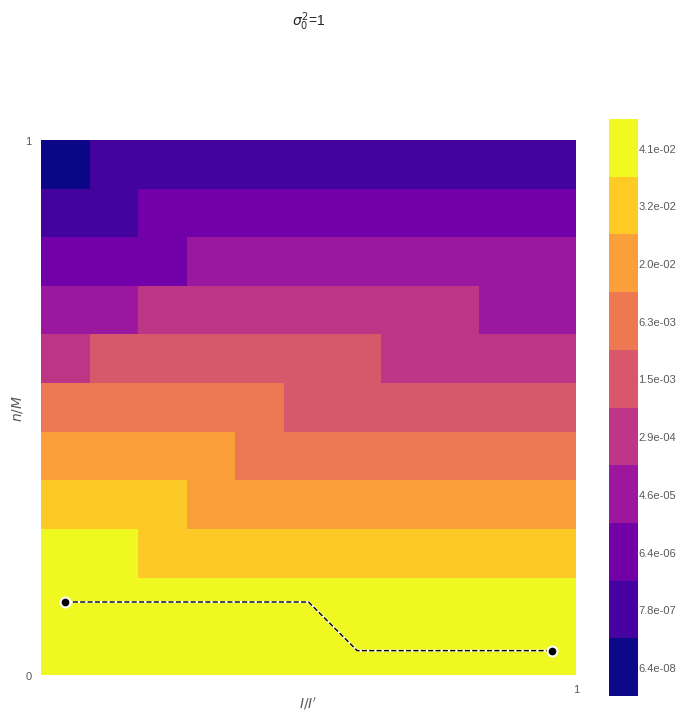

In [27]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter



M_temp=10
i0_temp=12.941141249834205
inat_temp=13.677744858488149
s2_temp=0.4031118178061155
n_max = M_temp + 1
n_bins = n_max

fig, axs = plt.subplots(1, 1, figsize=(7, 7))
cmap = custom_percentile_cmap

sys_model = NormPSM(M_temp, i0_temp, inat_temp, s2_temp, n_bins=M_temp+1)
prob_arr = sys_model.get_probs()
prob_arr_viz, value_map = get_percentiles(prob_arr)
ga_model = GAModel()
init_state = list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
path, probs = ga_model.get_best_path(prob_arr, minimize=False, init_state=init_state)
z_prob = prob_arr_viz[::-1]
c = axs.imshow(z_prob, extent=[0, 1, 0, 1], 
                cmap=cmap(len(value_map)),  interpolation='nearest')
x = [(x[1] / n_bins) + 0.5 * 1 / n_bins for x in path]
y = [(x[0] / (n_max)) + 0.5 * 1 / (n_max) for x in path]
cbar = fig.colorbar(c, ax=axs, shrink=0.9)
cticks = get_sticks(len(value_map))
ctick_labels = [f"{x:.1e}" for x in value_map]
cbar.set_ticks(cticks)
cbar.set_ticklabels(ctick_labels)
cbar.ax.tick_params(labelsize=8, pad=0.08)

axs.plot(x, y, '-', lw=1.5, color='white', zorder=1)
axs.plot(x, y, '--', lw=1, color='black', zorder=2)
axs.scatter([x[0], x[-1]], [y[0], y[-1]], marker="o", s=50, facecolors='black', edgecolors='white', linewidth=1.5, zorder=3, clip_on=False)


axs.set_title("".join([r'$\sigma _{0} ^{2}$', f"={s0}"]), fontsize=10, y=1.2)
axs.set_ylabel(r"$n / M$", fontsize=10, labelpad=0.1)
axs.set_xlabel(r"$I / I'$", fontsize=10, labelpad=0.1)

axs.grid(False)
axs.set_xticks([1])
axs.set_yticks([0, 1])
axs.tick_params(axis='both', which='major', labelsize=8)  # Ticks principais
axs.tick_params(axis='both', which='minor', labelsize=8)
axs.set_facecolor('none')       

fig.tight_layout(pad=0.01, w_pad=0.05, h_pad=0.05)

# plt.savefig(f"../temp_jupyter_plots/{today()}/reass_distribution_path_M{M}_{today()}.png")
# plt.savefig(f"../temp_jupyter_plots/{today()}/reass_distribution_path_M{M}_{today()}.svg")
plt.show()

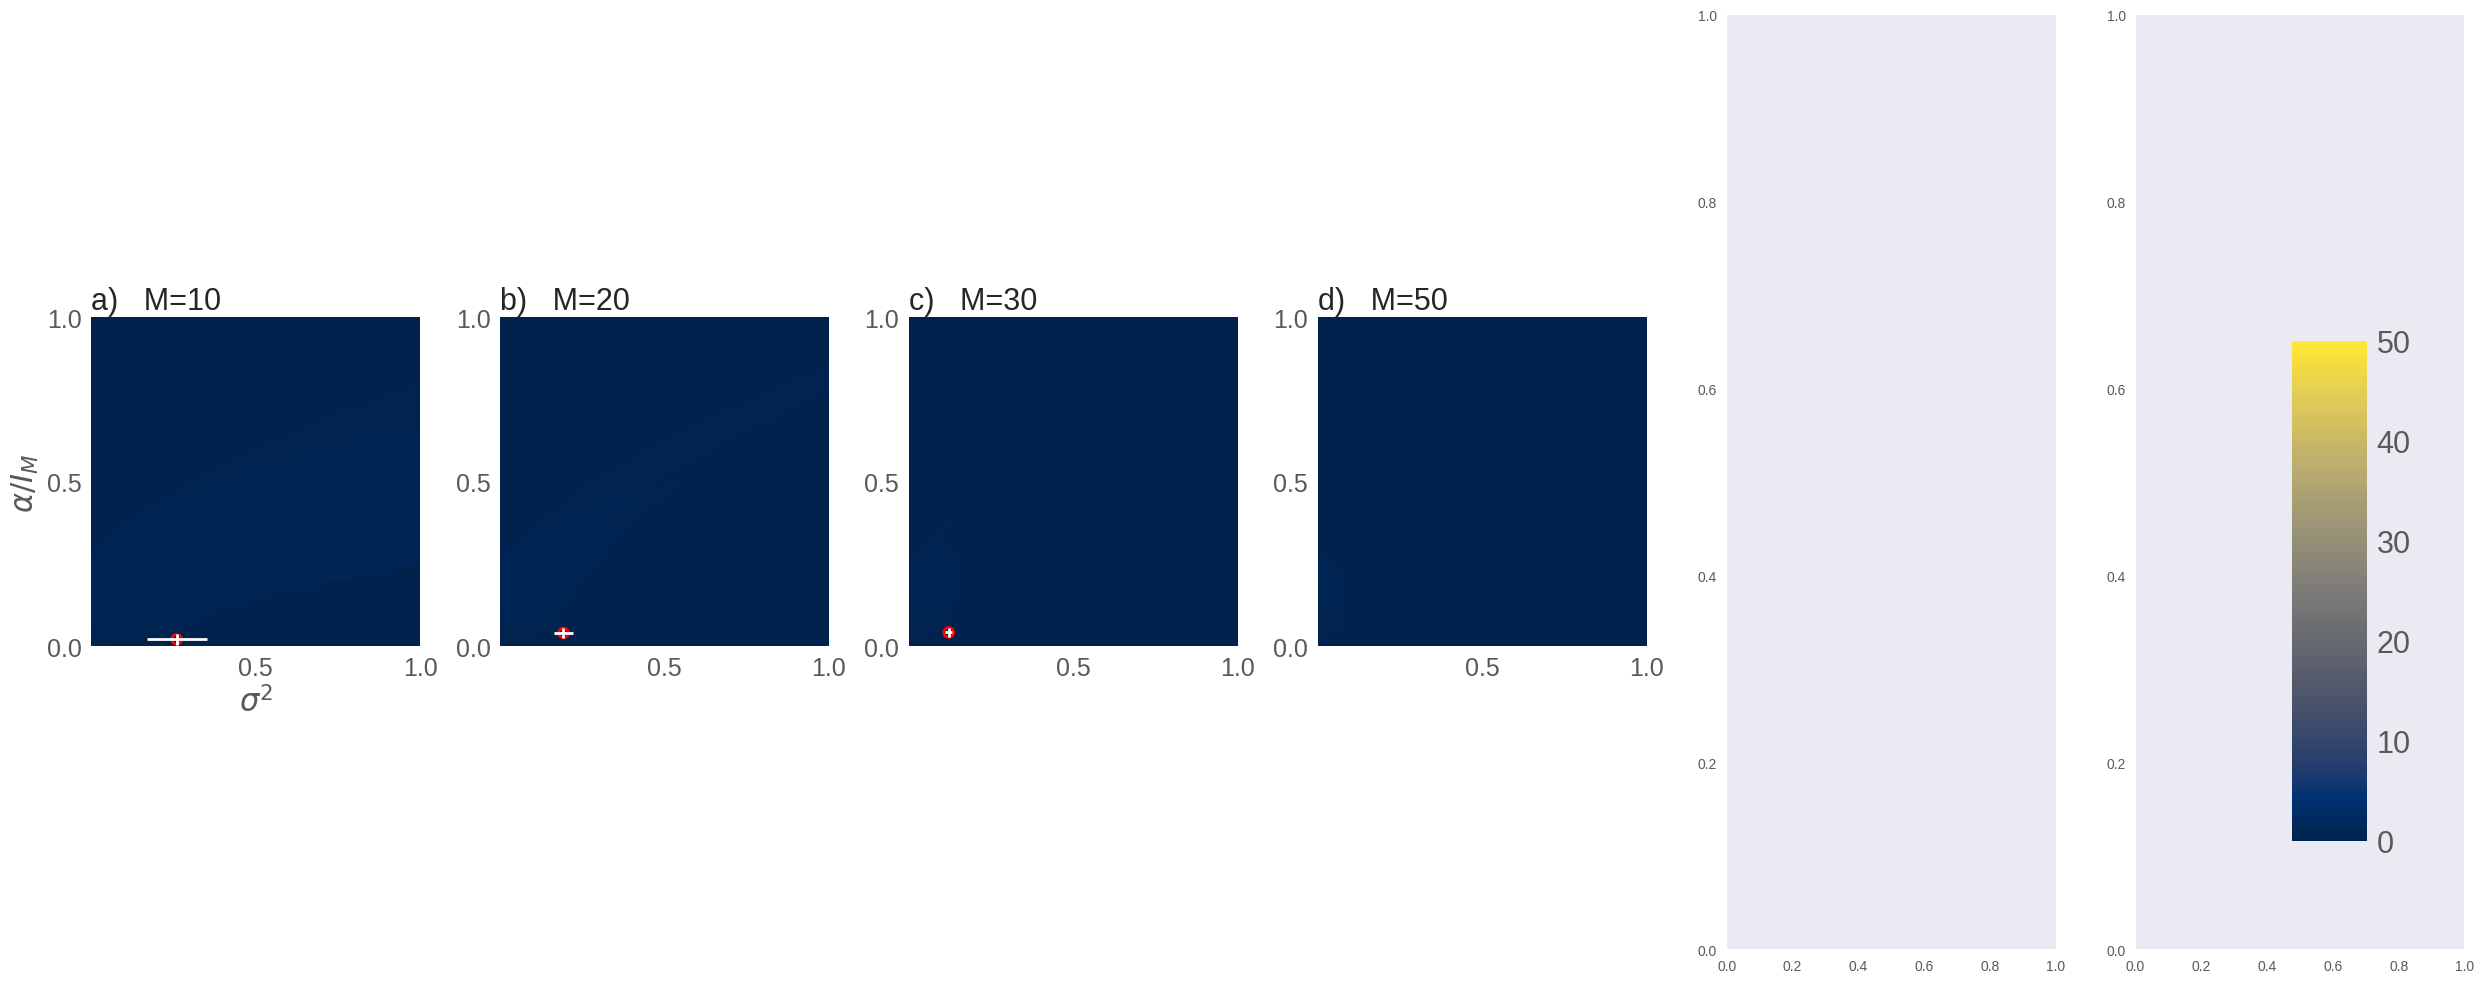

In [28]:
letters = ["a)", "b)", "c)", "d)", "e)", "f)"]

fig, axs = plt.subplots(1, 6, figsize=[25, 10])
cmap = plt.get_cmap("cividis")

# Definindo limites globais para a colorbar (vmin e vmax).
vmin = float('inf')
vmax = float('-inf')

# Calculando o intervalo da colorbar com base nos dados
for M in Ms:
    tps = np.load(f"temp_files/tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy")
    
    vmin = min(vmin, tps.min())
    vmax = max(vmax, tps.max())

# Variável para armazenar o primeiro heatmap (que será usado na colorbar)
first_heatmap = None
r_first_heatmap = None


# Gerando os subplots com os heatmaps
for idx, M in enumerate(Ms):

    tps = np.load(f"temp_files/tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}_lognorm.npy")
    
    c = axs[idx].imshow(tps, cmap=cmap, extent=[0, 1, 0, 1], interpolation='nearest', vmin=vmin, vmax=vmax)
    if first_heatmap is None:
        first_heatmap = c

    if idx == 0:
        axs[idx].set_ylabel(r"$ \alpha / I_M$", fontsize=22)
        axs[idx].set_xlabel(r"$\sigma^2$", fontsize=22)
    axs[idx].set_title(f"{letters[idx]}   M={M}", loc='left', fontsize=22)

    axs[idx].set_yticks([0, 0.5, 1])
    axs[idx].set_xticks([ 0.5, 1])
    axs[idx].tick_params(axis='both', which='major', labelsize=18)  # Ticks principais
    axs[idx].tick_params(axis='both', which='minor', labelsize=18)

    if idx == len(letters) - 1:

        for iter_idx, row in df_paper.iterrows():
        #systems = ["1BXR_AB", "2D1P_BC", "3RRL_AB", "2Y69_AC", "1EP3_AB", "2Y69_AB", "1RM6_AB"]
        #for idx2, system in enumerate(systems):

            # alpha_norm = df_paper[df_paper["Systems"] == system]["alpha_norm"].values[0]
            # alpha_norm = alpha_norm if alpha_norm < 1 else 1
            # df_var = df_paper[df_paper["Systems"] == system]["var"].values[0]

            if row["M"] not in [10, 20, 30]:
                alpha_norm = row["alpha_norm"]
                alpha_norm = alpha_norm if alpha_norm < 1 else 1
                df_var = row["var"]
                color = "red"
    
                axs[idx].scatter(df_var, alpha_norm, edgecolors=color, facecolors='none'
                                 , marker="s", s=50, linewidths=2, clip_on=False)
                axs[idx].set_y_lim=([-0.1, 1])
                #axs[idx].legend()


dfs_parags = []
for idx_plot, paralog in enumerate([10, 20, 30]):

    i_nat_paralog = np.load(f"../dados_paralogos/I'_paralogos_{paralog}seqs.npy")
    i_0_paralog = np.load(f"../dados_paralogos/I0_paralogos_{paralog}seqs.npy")
    s_0_paralog = np.load(f"../dados_paralogos/sigma0_paralogos_{paralog}seqs.npy")

    ga_tps = np.load(f"../dados_paralogos/tp_without_reass_paralogos_{paralog}seqs.npy")
    ga_r_tps = np.load(f"../dados_paralogos/tp_with_reass_paralogos_{paralog}seqs.npy")


    alphas_paralog = (i_nat_paralog - i_0_paralog) / 50

    tps_paralogs = [get_tp(paralog, i_0_paralog[x_pg], i_nat_paralog[x_pg], s_0_paralog[x_pg]) for x_pg in range(len(i_0_paralog))]
    r_tps_paralogs = [get_r_tp(paralog, i_0_paralog[x_pg], i_nat_paralog[x_pg], s_0_paralog[x_pg]) for x_pg in range(len(i_0_paralog))]


    df_parag = pd.DataFrame({"M": [paralog] * len(tps_paralogs),
                             "model_tps": tps_paralogs,
                             "model_tps_std_dev": np.std(tps_paralogs),
                             "model_r_tps": r_tps_paralogs,
                             "model_r_tps_std_dev": np.std(r_tps_paralogs),
                             "ga_tps": ga_tps,
                             "ga_r_tps": ga_r_tps
                            })
    
    dfs_parags.append(df_parag)
    

    # for idx_tp, tp_model in enumerate(tps_paralogs):
    #     if tp_model > 0.25:
    #         color = "lightgreen"
    #     else:
    #         color = "red"

    #     axs[idx_plot].scatter(s_0_paralog[idx_tp], alphas_paralog[idx_tp], edgecolors=color, facecolors='none', marker="o", s=50, linewidths=2)
    #     axs[idx_plot].set_y_lim=([-0.1, 1])

    tp_mean = np.mean(tps_paralogs)
    if tp_mean > 0.25:
        color = "lightgreen"
    else:
        color = "red"

    axs[idx_plot].errorbar(np.mean(s_0_paralog), np.mean(alphas_paralog), xerr=np.std(s_0_paralog), yerr=np.std(alphas_paralog), fmt='none', 
             ecolor='white', capsize=15, label='Data points')
    axs[idx_plot].scatter(np.mean(s_0_paralog), np.mean(alphas_paralog), edgecolors=color, facecolors='none', marker="o", s=50, linewidths=2)
    axs[idx_plot].set_y_lim=([-0.1, 1])

    #cbar = fig.colorbar(c, ax=axs[idx])
pd.concat(dfs_parags).to_csv("paralogos.csv")

# Ajustando o layout

# Ajustando o layout
plt.tight_layout()

cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.5])  # Posição [esquerda, inferior, largura, altura]
cbar = fig.colorbar(first_heatmap, cax=cbar_ax)  
cbar.ax.tick_params(labelsize=22)

# Salvando a figura
plt.savefig(f"../temp_jupyter_plots/{today()}/TPS_i0xs0_range_inat{i_nat}_{today()}.png")
plt.savefig(f"../temp_jupyter_plots/{today()}/TPS_i0xs0_range_inat{i_nat}_{today()}.svg")
plt.show()

M10 - 0.49375(0.07500000000000001+-0.075)
M20 - 0.3125(0.0125+-0.02165063509461097)
M30 - 0.20555555555555557(0.016666666666666666+-0.016666666666666666)


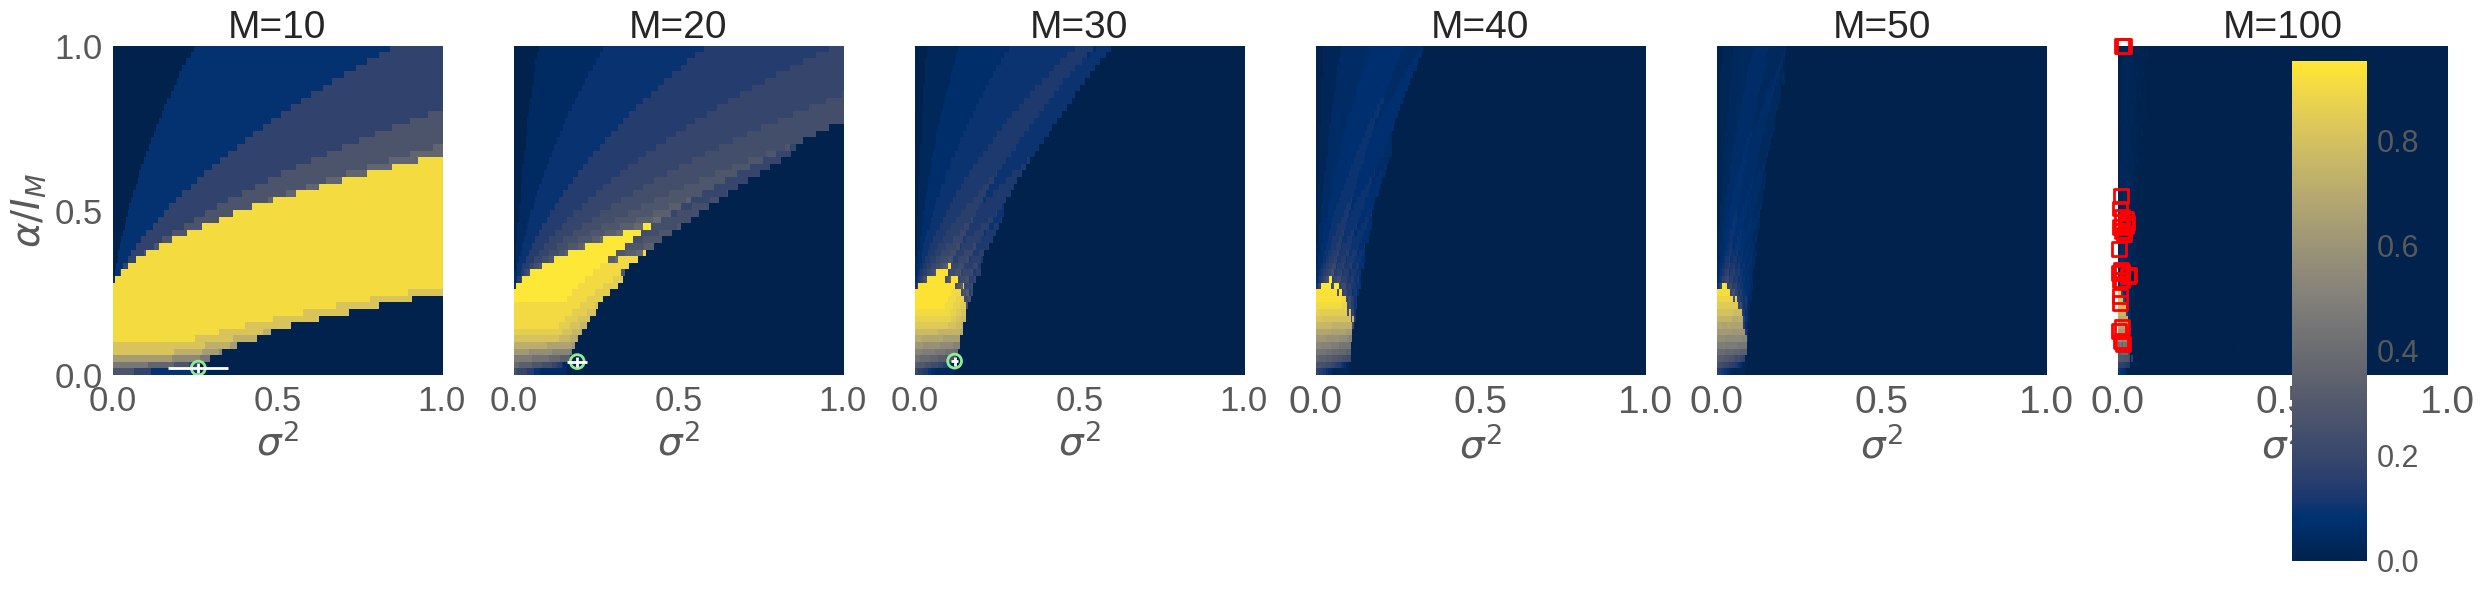

In [20]:
letters = ["a)", "b)", "c)", "d)", "e)", "f)"]

fig, axs = plt.subplots(1, 6, figsize=[25, 10])
cmap = plt.get_cmap("cividis")

# Definindo limites globais para a colorbar (vmin e vmax).
vmin = float('inf')
vmax = float('-inf')

# Calculando o intervalo da colorbar com base nos dados
for M in Ms:
    tps = np.load(f"temp_files/tp_only/tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy")
    
    vmin = min(vmin, tps.min())
    vmax = max(vmax, tps.max())

# Variável para armazenar o primeiro heatmap (que será usado na colorbar)
first_heatmap = None
r_first_heatmap = None


# Gerando os subplots com os heatmaps
for idx, M in enumerate(Ms):

    tps = np.load(f"temp_files/tp_only/tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy")
    
    c = axs[idx].imshow(tps, cmap=cmap, extent=[0, 1, 0, 1], interpolation='nearest', vmin=vmin, vmax=vmax)
    if first_heatmap is None:
        first_heatmap = c

    if idx == 0:
        axs[idx].set_ylabel(r"$ \alpha / I_M$", fontsize=28)
        
        axs[idx].set_yticks([0, 0.5, 1])
    else:
        axs[idx].set_yticks([])

    axs[idx].set_xlabel(r"$\sigma^2$", fontsize=28)
    axs[idx].set_title(f"M={M}", fontsize=28)
    axs[idx].set_xticks([0, 0.5, 1])
    axs[idx].tick_params(axis='both', which='major', labelsize=28)  # Ticks principais
    axs[idx].tick_params(axis='both', which='minor', labelsize=28)

    if idx == len(letters) - 1:

        for iter_idx, row in df_paper.iterrows():
        #systems = ["1BXR_AB", "2D1P_BC", "3RRL_AB", "2Y69_AC", "1EP3_AB", "2Y69_AB", "1RM6_AB"]
        #for idx2, system in enumerate(systems):

            # alpha_norm = df_paper[df_paper["Systems"] == system]["alpha_norm"].values[0]
            # alpha_norm = alpha_norm if alpha_norm < 1 else 1
            # df_var = df_paper[df_paper["Systems"] == system]["var"].values[0]

            if row["M"] not in [10, 20, 30]:
                alpha_norm = row["alpha_norm"]
                alpha_norm = alpha_norm if alpha_norm < 1 else 1
                df_var = row["var"]
                color = "red"
    
                axs[idx].scatter(df_var, alpha_norm, edgecolors=color, facecolors='none'
                                 , marker="s", s=100, linewidths=2, clip_on=False)
                axs[idx].set_y_lim=([-0.1, 1])
                #axs[idx].legend()


dfs_parags = []
for idx_plot, paralog in enumerate([10, 20, 30]):

    i_nat_paralog = np.load(f"../dados_paralogos/I'_paralogos_{paralog}seqs.npy")
    i_0_paralog = np.load(f"../dados_paralogos/I0_paralogos_{paralog}seqs.npy")
    s_0_paralog = np.load(f"../dados_paralogos/sigma0_paralogos_{paralog}seqs.npy")

    ga_tps = np.load(f"../dados_paralogos/tp_without_reass_paralogos_{paralog}seqs.npy")
    ga_r_tps = np.load(f"../dados_paralogos/tp_with_reass_paralogos_{paralog}seqs.npy")


    alphas_paralog = (i_nat_paralog - i_0_paralog) / 50

    tps_paralogs = [get_tp(paralog, i_0_paralog[x_pg], i_nat_paralog[x_pg], s_0_paralog[x_pg]) for x_pg in range(len(i_0_paralog))]
    r_tps_paralogs = [get_r_tp(paralog, i_0_paralog[x_pg], i_nat_paralog[x_pg], s_0_paralog[x_pg]) for x_pg in range(len(i_0_paralog))]


    df_parag = pd.DataFrame({"M": [paralog] * len(tps_paralogs),
                             "model_tps": tps_paralogs,
                             "model_tps_std_dev": np.std(tps_paralogs),
                             "model_r_tps": r_tps_paralogs,
                             "model_r_tps_std_dev": np.std(r_tps_paralogs),
                             "ga_tps": ga_tps,
                             "ga_r_tps": ga_r_tps
                            })
    
    dfs_parags.append(df_parag)

    print(f"M{paralog} - {np.mean(ga_tps)}({np.mean(tps_paralogs)}+-{np.std(tps_paralogs)})")

    # for idx_tp, tp_model in enumerate(tps_paralogs):
    #     if tp_model > 0.25:
    #         color = "lightgreen"
    #     else:
    #         color = "red"

    #     axs[idx_plot].scatter(s_0_paralog[idx_tp], alphas_paralog[idx_tp], edgecolors=color, facecolors='none', marker="o", s=50, linewidths=2)
    #     axs[idx_plot].set_y_lim=([-0.1, 1])

    tp_mean = np.mean(tps_paralogs)
    if tp_mean > 0.0:
        color = "lightgreen"
    else:
        color = "red"

    axs[idx_plot].errorbar(np.mean(s_0_paralog), np.mean(alphas_paralog), xerr=np.std(s_0_paralog), yerr=np.std(alphas_paralog), fmt='none', 
             ecolor='white', capsize=15, label='Data points')
    axs[idx_plot].scatter(np.mean(s_0_paralog), np.mean(alphas_paralog), edgecolors=color, facecolors='none', marker="o", s=100, linewidths=2)
    axs[idx_plot].set_y_lim=([-0.1, 1])
    axs[idx_plot].tick_params(axis='both', which='major', labelsize=25)  # Ticks principais
    axs[idx_plot].tick_params(axis='both', which='minor', labelsize=25)

    #cbar = fig.colorbar(c, ax=axs[idx])
pd.concat(dfs_parags).to_csv("paralogos.csv")

# Ajustando o layout

# Ajustando o layout
plt.tight_layout()

cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.5])  # Posição [esquerda, inferior, largura, altura]
cbar = fig.colorbar(first_heatmap, cax=cbar_ax)  
cbar.ax.tick_params(labelsize=22)

# Salvando a figura
plt.savefig(f"../temp_jupyter_plots/{today()}/TPS_i0xs0_range_inat{i_nat}_{today()}.png")
plt.savefig(f"../temp_jupyter_plots/{today()}/TPS_i0xs0_range_inat{i_nat}_{today()}.svg")
plt.show()

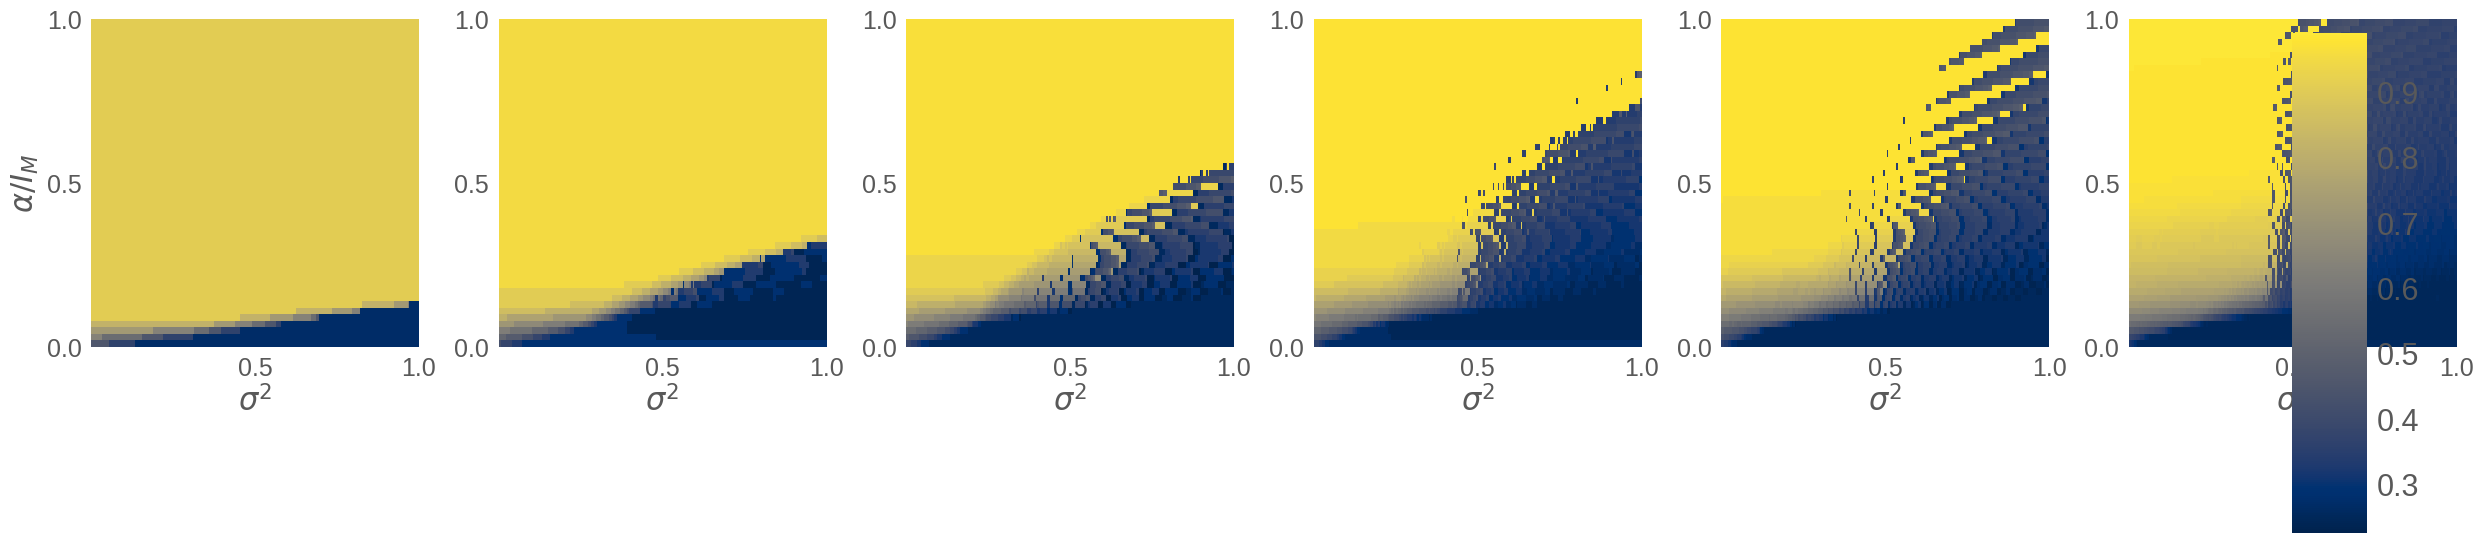

In [28]:
letters = ["a)", "b)", "c)", "d)", "e)", "f)"]

fig, axs = plt.subplots(1, 6, figsize=[25, 10])
cmap = plt.get_cmap("cividis")

# Definindo limites globais para a colorbar (vmin e vmax).
vmin = float('inf')
vmax = float('-inf')

# Calculando o intervalo da colorbar com base nos dados
for M in Ms:
    tps = np.load(f"temp_files/tp_only/reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy")
    
    vmin = min(vmin, tps.min())
    vmax = max(vmax, tps.max())

# Variável para armazenar o primeiro heatmap (que será usado na colorbar)
first_heatmap = None
r_first_heatmap = None

# Gerando os subplots com os heatmaps
for idx, M in enumerate(Ms):

    tps = np.load(f"temp_files/tp_only/reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy")
    
    c = axs[idx].imshow(tps, cmap=cmap, extent=[0, 1, 0, 1], interpolation='nearest', vmin=vmin, vmax=vmax)
    if first_heatmap is None:
        first_heatmap = c

    if idx == 0:
        axs[idx].set_ylabel(r"$ \alpha / I_M$", fontsize=22)
    axs[idx].set_xlabel(r"$\sigma^2$", fontsize=22)
    #axs[idx].set_title(f"{letters[idx]}   M={M}", loc='left', fontsize=22)

    axs[idx].set_yticks([0, 0.5, 1])
    axs[idx].set_xticks([ 0.5, 1])
    axs[idx].tick_params(axis='both', which='major', labelsize=18)  # Ticks principais
    axs[idx].tick_params(axis='both', which='minor', labelsize=18)

    # if idx == len(letters) - 1:
    #     systems = ["1BXR_AB", "2D1P_BC", "3RRL_AB", "2Y69_AC", "1EP3_AB", "2Y69_AB", "1RM6_AB"]
    #     marks = ['o', 's', '^', 'D', 'v', 'P', '*']
    #     for idx2, system in enumerate(systems):
    #         scatter_color = cmap((sys_dict[system][2] - vmin) / (vmax - vmin))  # Normalizando para o cmap
    #         axs[idx].scatter(sys_dict[system][1], sys_dict[system][0], color=scatter_color, label=system, edgecolor='white', linewidth=0.5, marker=marks[idx2])
    #         axs[idx].set_y_lim=([-0.1, 1])
    #         axs[idx].legend()


    #cbar = fig.colorbar(c, ax=axs[idx])

# Ajustando o layout

# Ajustando o layout
plt.tight_layout()

cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.5])  # Posição [esquerda, inferior, largura, altura]
cbar = fig.colorbar(first_heatmap, cax=cbar_ax)  
cbar.ax.tick_params(labelsize=22)

# Salvando a figura
plt.savefig(f"../temp_jupyter_plots/{today()}/reass_TPS_i0xs0_range_inat{i_nat}_{today()}.png")
plt.savefig(f"../temp_jupyter_plots/{today()}/reass_TPS_i0xs0_range_inat{i_nat}_{today()}.svg")
plt.show()

In [ ]:
Ms = [10, 20, 30, 40, 50, 100, 200]
i_0s = np.arange(0, 50)
i_0s[0] = 0.1
sigmas2_0 = np.arange(0.000, 1, 0.005)
sigmas2_0[0] = 0.001


for M in Ms:

    M_file = f"temp_files/tp_only/reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy"
    if not os.path.exists(M_file):

        print(f"Getting temp_files/reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy")
    
        n_max = M + 1 
        n_bins = M + 1 
        
        tps = np.zeros([len(i_0s), len(sigmas2_0), 4], dtype=float)
        restart_file =  f"temp_files/restart_file_reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy"
        restart_idx = f"temp_files/restart_idx0_reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy"

        if os.path.exists(restart_file):
            tps = np.load(restart_file)
            idx0 = np.load(restart_idx)
        else:
            tps = np.zeros([len(i_0s), len(sigmas2_0), 4], dtype=float)
            idx0 = 0
        
        for idx1 in range(int(idx0), len(i_0s)):
            for idx2 in range(len(sigmas2_0)):

                print(f"{idx1}-i0={i_0s[idx1]}; {idx2}-s0={sigmas2_0[idx2]}")
                
                sys_model = NormPSM(M, i_0s[idx1], i_nat, sigmas2_0[idx2], n_bins=n_bins)
                prob_arr = sys_model.reassessment_probs(sys_model.get_probs())
                ga_model = GAModel()
                init_state = list(np.unravel_index(np.argmax(prob_arr), prob_arr.shape))
                path = ga_model.get_best_path(prob_arr, minimize=minimize, init_state=init_state)[0]
                
                tps[idx1, idx2, :] = [path[0][0], path[0][1], path[-1][0], path[-1][1]] #path[-1][0] / n_max

            np.save(f"temp_files/restart_file_reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy", tps)
            np.save(f"temp_files/restart_idx0_reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy", [idx1 + 1])
                
        np.save(f"temp_files/reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy", tps)

In [ ]:
letters = ["a)", "b)", "c)", "d)", "e)", "f)"]

fig, axs = plt.subplots(1, 6, figsize=[55, 10])
cmap = plt.get_cmap("cividis")
vmin = 0
vmax = 1


#absolute_gap

arr_i0s = np.zeros((len(i_0s), len(sigmas2_0)), dtype="float")
for i in range(len(sigmas2_0)):
    arr_i0s[:, i] = i_0s

arr_inats = np.ones((len(i_0s), len(sigmas2_0)), dtype="float") * i_nat

arr_gaps = arr_inats - arr_i0s

for idx, M in enumerate(Ms):
    data_tps = np.load(f"temp_files/reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy")

    traj_n0 = data_tps[:, :, 0]
    traj_i0 = data_tps[:, :, 1]
    traj_nf = data_tps[:, :, 2]
    traj_if = data_tps[:, :, 3]
    bin_value = arr_gaps / M

    i_init_bin = bin_value * traj_i0 + arr_i0s
    i_final_bin = bin_value * (traj_if + 1) + arr_i0s
    
    alt_alpha_if =  (i_final_bin - i_init_bin) / i_final_bin
    
    tps = traj_nf / M
    
    tps_norm = np.clip(tps, vmin, vmax)

    for i in range(len(intervals) -1):
        filtro = np.where((tps.flatten() >= intervals[i]) & (tps.flatten() < intervals[i + 1]))
        sc = axs[idx].scatter(np.array(sigmas2_0.tolist() * len(i_0s))[filtro], alt_alpha_if.flatten()[filtro] , c=tps.flatten()[filtro], cmap=cmap, vmin=vmin, vmax=vmax)

    axs[idx].set_ylabel(r"$ \alpha* / I*$")
    axs[idx].set_xlabel(r"$\sigma^2$")
    axs[idx].set_title(f"{letters[idx]}   M={M}", loc='left')

cbar = fig.colorbar(sc, ax=axs, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label("tps (Normalized)", fontsize=14)

plt.savefig(f"../temp_jupyter_plots/{today()}/reass_alpha_alt_norm_if_TP_inat{i_nat}_{today()}.png")
plt.savefig(f"../temp_jupyter_plots/{today()}/reass_alpha_alt_norm_if_TP_inat{i_nat}_{today()}.svg")

plt.show()

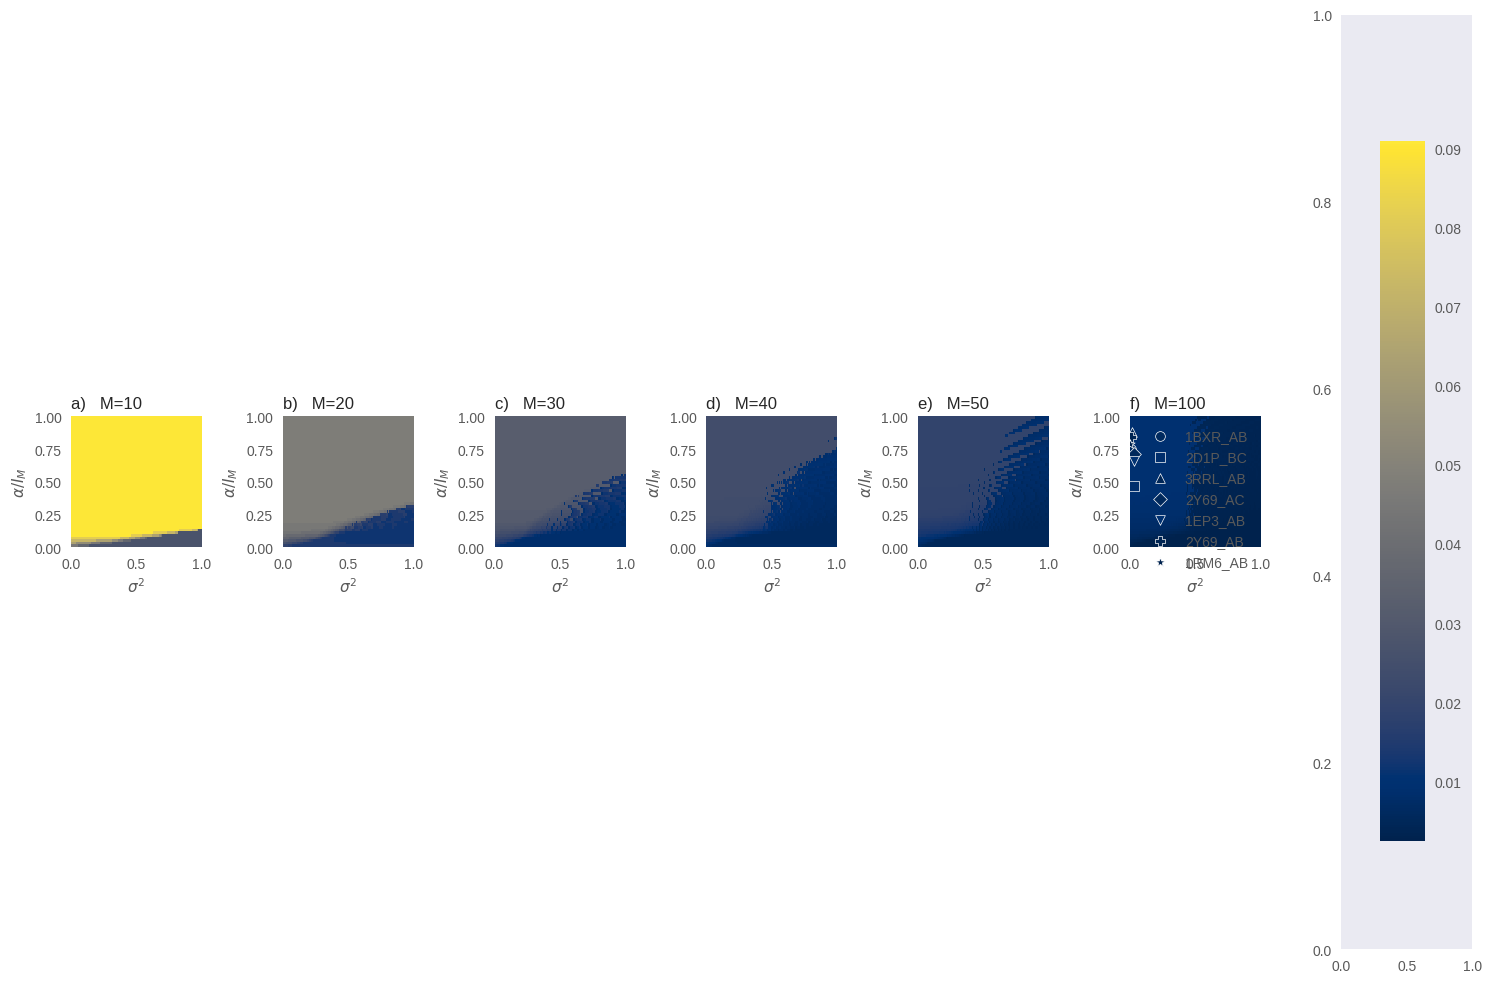

In [12]:
letters = ["a)", "b)", "c)", "d)", "e)", "f)"]

fig, axs = plt.subplots(1, 7, figsize=[15, 10])
cmap = plt.get_cmap("cividis")

# Definindo limites globais para a colorbar (vmin e vmax).
vmin = float('inf')
vmax = float('-inf')

# Calculando o intervalo da colorbar com base nos dados
for M in Ms:
    data_tps = np.load(f"temp_files/tp_only/reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy")
    traj_nf = data_tps
    tps = traj_nf / M
    
    vmin = min(vmin, tps.min())
    vmax = max(vmax, tps.max())

# Variável para armazenar o primeiro heatmap (que será usado na colorbar)
first_heatmap = None

# Gerando os subplots com os heatmaps
for idx, M in enumerate(Ms):

    data_tps = np.load(f"temp_files/tp_only/reass_tp_i0{i_0s[0]}-{i_0s[-1]}_s0{sigmas2_0[0]}-{sigmas2_0[-1]}_m{M}_inat{i_nat}.npy")
    traj_nf = data_tps
    tps = traj_nf / M
    c = axs[idx].imshow(tps, cmap=cmap, extent=[0, 1, 0, 1], interpolation='nearest', vmin=vmin, vmax=vmax)

    # Armazenando a referência do primeiro heatmap
    if first_heatmap is None:
        first_heatmap = c

    axs[idx].set_ylabel(r"$ \alpha / I_M$")
    axs[idx].set_xlabel(r"$\sigma^2$")
    axs[idx].set_title(f"{letters[idx]}   M={M}", loc='left')

    if idx == len(letters) - 1:
        systems = ["1BXR_AB", "2D1P_BC", "3RRL_AB", "2Y69_AC", "1EP3_AB", "2Y69_AB", "1RM6_AB"]
        marks = ['o', 's', '^', 'D', 'v', 'P', '*']
        for idx2, system in enumerate(systems):
            scatter_color = cmap((sys_dict[system][2] - vmin) / (vmax - vmin))  # Normalizando para o cmap
            axs[idx].scatter(sys_dict[system][1], sys_dict[system][0], color=scatter_color, label=system, edgecolor='white', linewidth=0.5, marker=marks[idx2])
            axs[idx].set_y_lim=([-0.1, 1])
            axs[idx].legend()


# Ajustando o layout

# Ajustando o layout
plt.tight_layout()

# Criando a colorbar única ao lado dos subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7])  # Posição [esquerda, inferior, largura, altura]
fig.colorbar(first_heatmap, cax=cbar_ax)  # Usando o primeiro heatmap criado

# Salvando a figura
plt.savefig(f"../temp_jupyter_plots/{today()}/reass_TPS_i0xs0_range_inat{i_nat}_{today()}.png")
plt.savefig(f"../temp_jupyter_plots/{today()}/reass_TPS_i0xs0_range_inat{i_nat}_{today()}.svg")
plt.show()


## Alpha x TP Rate dependence

In [ ]:
i_nat = 50
n_step = 1
minimize = False

In [ ]:
ln_files = {}
rln_files = {}
n_files = {}
rn_files = {}

Ms = [10, 30, 50, 70, 90, 110, 130]

i0s = np.arange(1, (i_nat - 1), 1)

sigmas2_0 = [0.002, 0.005, 0.008, 0.01, 0.02, 0.03, 0.04, 0.05]
#sigmas2_0 = [0.01, 0.02, 0.03, 0.04, 0.05]

for idx, sigma2_0 in enumerate(sigmas2_0):
    for M in Ms:
        
        ln_file = f"temp_files/e_ln_alphaxtp_sigma{sigma2_0}_m{M}.npy"
        rln_file = f"temp_files/e_rln_alphaxtp_sigma{sigma2_0}_m{M}.npy"
        n_file = f"temp_files/e_n_alphaxtp_sigma{sigma2_0}_m{M}.npy"
        rn_file = f"temp_files/e_rn_alphaxtp_sigma{sigma2_0}_m{M}.npy"
        
        if not os.path.exists(ln_file):
            
            pass
            
            ln_alphas = []
            ln_tps = []
            rln_tps = []
            n_alphas = []
            n_tps = []
            rn_tps = []

            for i0 in i0s:

                ln_psm = LogNormPSM(M, i0, i_nat, sigma2_0)
                n_psm = NormPSM(M, i0, i_nat, sigma2_0)

                ln_alphas.append(ln_psm.get_alpha())
                n_alphas.append(n_psm.get_alpha())

                ga_model = GAModel()
                
                tolerance = 0.001
                
                ln_probs = ln_psm.get_probs()
                if not np.isclose(np.sum(ln_probs), 1, atol=tolerance):
                   print(f"M={M} sigma2_0={sigma2_0} i0={i0} - ln probs sum = {np.sum(ln_probs)}")
                
                rln_probs = ln_psm.reassessment_probs(ln_psm.get_probs())
                if not np.isclose(np.sum(rln_probs), 1, atol=tolerance):
                   print(f"M={M} sigma2_0={sigma2_0} i0={i0} - ln probs sum = {np.sum(rln_probs)}")
                
                n_probs = n_psm.get_probs()
                if not np.isclose(np.sum(n_probs), 1, atol=tolerance):
                    print(f"M={M} sigma2_0={sigma2_0} i0={i0} - n probs sum = {np.sum(n_probs)}")
                    
                rn_probs = n_psm.reassessment_probs(n_psm.get_probs())
                if not np.isclose(np.sum(rn_probs), 1, atol=tolerance):
                    print(f"M={M} sigma2_0={sigma2_0} i0={i0} - n probs sum = {np.sum(rn_probs)}")

                    
                # path tp    
                    
                ln_path, ln_step_probs = ga_model.get_best_path(ln_probs, minimize=minimize)
                rln_path, rln_step_probs = ga_model.get_best_path(rln_probs, minimize=minimize)
                n_path, n_step_probs = ga_model.get_best_path(n_probs, minimize=minimize)
                rn_path, rn_step_probs = ga_model.get_best_path(rn_probs, minimize=minimize)
                      
                ln_tps.append(ln_path[-1][0] / M)
                rln_tps.append(rln_path[-1][0] / M)
                n_tps.append(n_path[-1][0] / M)
                rn_tps.append(rn_path[-1][0] / M)

                
                ######################################################################################
                
                # kolmogorov tp

                # def kolm(arr, k_stps):

                #     k_arr = np.copy(arr)

                #     for k in range(k_stps - 1):
                #         k_arr = np.dot(k_arr, arr)

                #     return k_arr
            
                # _ln_transitions, ln_indexes = ga_model.get_transitions_matrix(ln_probs)
                # _rln_transitions, rln_indexes = ga_model.get_transitions_matrix(rln_probs)
                # _n_transitions, n_indexes = ga_model.get_transitions_matrix(n_probs)
                # _rn_transitions, rn_indexes = ga_model.get_transitions_matrix(rn_probs)
     
                # ln_transitions = np.linalg.matrix_power(_ln_transitions, ln_probs.shape[1] - 1)
                # rln_transitions = np.linalg.matrix_power(_rln_transitions, rln_probs.shape[1] - 1)
                # n_transitions = np.linalg.matrix_power(_n_transitions, n_probs.shape[1] - 1)
                # rn_transitions = np.linalg.matrix_power(_rn_transitions, rn_probs.shape[1] - 1)

                # kln_transitions = kolm(_ln_transitions, ln_probs.shape[1] - 1)
                # krln_transitions = kolm(_rln_transitions, rln_probs.shape[1] - 1)
                # kn_transitions = kolm(_n_transitions, n_probs.shape[1] - 1)
                # krn_transitions = kolm(_rn_transitions, rn_probs.shape[1] - 1)

                # ln_best_index = np.argmax(ln_transitions[0])
                # ln_tps.append(ln_indexes[ln_best_index][0] / M)
                
                # rln_best_index = np.argmax(rln_transitions[0])
                # rln_tps.append(rln_indexes[rln_best_index][0] / M)
                
                # n_best_index = np.argmax(n_transitions[0])
                # n_tps.append(n_indexes[n_best_index][0] / M)
                
                # rn_best_index = np.argmax(rn_transitions[0])
                # rn_tps.append(rn_indexes[rn_best_index][0] / M)
                


                ######################################################################################
          

            # lognormal
            order_x = np.argsort(ln_alphas)
            ln_sorted_alphas = [ln_alphas[x] for x in order_x]
            ln_sorted_tps = [ln_tps[x] for x in order_x]
            rln_sorted_tps = [rln_tps[x] for x in order_x]
            # normal
            order_x = np.argsort(n_alphas)
            n_sorted_alphas = [n_alphas[x] for x in order_x]
            n_sorted_tps = [n_tps[x] for x in order_x]
            rn_sorted_tps = [rn_tps[x] for x in order_x]
            
            np.save(ln_file, [ln_sorted_alphas, ln_sorted_tps])
            np.save(rln_file, [ln_sorted_alphas, rln_sorted_tps])
            np.save(n_file, [n_sorted_alphas, n_sorted_tps])
            np.save(rn_file, [n_sorted_alphas, rn_sorted_tps])

        ln_files[f"{sigma2_0}_{M}"] = ln_file
        rln_files[f"{sigma2_0}_{M}"] = rln_file
        n_files[f"{sigma2_0}_{M}"] = n_file
        rn_files[f"{sigma2_0}_{M}"] = rn_file


In [ ]:
fig, axs = plt.subplots(5, 2, figsize=[20, 45])

for idx, sigma2_0 in enumerate(sigmas2_0):
    for M in Ms:      
    
        ln_arr = np.load(ln_files[f"{sigma2_0}_{M}"])
        axs[idx, 0].plot(ln_arr[0], ln_arr[1], label=f"M={M}")
        axs[idx, 0].set_title("".join(["LOGNORMAL - ", r'$\sigma^{2} _{0}$',f" :{sigma2_0}; gap max={i_nat - i0s[0]}"]))
        axs[idx, 0].set_xlabel(r'$\alpha$')
        axs[idx, 0].set_ylabel("tp")
        axs[idx, 0].legend()
        
        n_arr = np.load(n_files[f"{sigma2_0}_{M}"])
        axs[idx, 1].plot(n_arr[0], n_arr[1], label=f"M={M}")
        axs[idx, 1].set_title("".join(["NORMAL - ", r'$\sigma^{2} _{0}$',f" :{sigma2_0}; gap max={i_nat - i0s[0]}"]))
        axs[idx, 1].set_xlabel(r'$\alpha$')
        axs[idx, 1].set_ylabel("tp")
        axs[idx, 1].legend()


plt.savefig("../temp_jupyter_plots/alphaxtp.png")
plt.show()


In [ ]:
fig, axs = plt.subplots(5, 2, figsize=[20, 45])

for idx, sigma2_0 in enumerate(sigmas2_0):
    for M in Ms:      
    
        ln_arr = np.load(rln_files[f"{sigma2_0}_{M}"])
        axs[idx, 0].plot(ln_arr[0], ln_arr[1], label=f"M={M}")
        axs[idx, 0].set_title("".join(["LOGNORMAL - ", r'$\sigma^{2} _{0}$',f" :{sigma2_0}; gap max={i_nat - i0s[0]}"]))
        axs[idx, 0].set_xlabel(r'$\alpha$')
        axs[idx, 0].set_ylabel("tp")
        axs[idx, 0].legend()
        
        n_arr = np.load(rn_files[f"{sigma2_0}_{M}"])
        axs[idx, 1].plot(n_arr[0], n_arr[1], label=f"M={M}")
        axs[idx, 1].set_title("".join(["NORMAL - ", r'$\sigma^{2} _{0}$',f" :{sigma2_0}; gap max={i_nat - i0s[0]}"]))
        axs[idx, 1].set_xlabel(r'$\alpha$')
        axs[idx, 1].set_ylabel("tp")
        axs[idx, 1].legend()


plt.savefig("../temp_jupyter_plots/alphaxrtp.png")
plt.show()


/home/jafiorote/miniconda3/envs/ga_error_sources/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "
/home/jafiorote/miniconda3/envs/ga_error_sources/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "
/home/jafiorote/miniconda3/envs/ga_error_sources/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "
/home/jafiorote/miniconda3/envs/ga_er

###### 